## Import Library

In [1]:
#--- Data Manipulation ---
import pandas as pd
import numpy as np
from scipy.sparse import hstack
from tabulate import tabulate
#---- Data Visualization ---  
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud
#--- Text Preprocessing ---
import re 
import nltk 
nltk.data.path.append('/Users/macbookair/nltk_data')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from langdetect import detect
from transformers import MarianMTModel, MarianTokenizer
nltk.download('averaged_perceptron_tagger_eng')
from langdetect import detect, DetectorFactory
#--- Recommendation System ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity  
import ipywidgets as widgets
from IPython.display import display
import itertools
#--- Set Display Options ---
from difflib import ndiff
from IPython.display import HTML
#--- Ignore Warnings ---
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [2]:
pd.set_option('display.max_colwidth', None)

## Import dataset

In [3]:
df = pd.read_csv('/Users/macbookair/Script/Skripsi/utils/DATASET/fix_recommendation_system_dataset.csv')
df.head()

,no,id_document,tahun_terbit,nama_jurnal,judul_artikel,nama_penulis,kata_kunci,abstrak
0,1,doc1,2025,"ZERO: Jurnal Sains, Matermatika, dan Terapan","Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia","Arie Wahyu Wijayanto, Rindang Bangun Prasetyo, Salwa Rizqina Putri, Sugiarto Sugiarto, Waris Marsisno, Krismanti Tri Wahyuni, Ernawati Pasaribu, Meilinda F N Maghfiroh",Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,"The rapid conversion of farmland to non-agricultural uses in West Java threatens food security, farmer livelihoods, and environmental sustainability. This study investigates the causes and consequences of land conversion in West Bandung and Purwakarta Regencies using a mixed-source data, including geotagging, CAPI, and secondary data from satellite images, focusing on landowners who converted farmland between 2013 and 2021. Multiple linear regression and spatial models, including Spatial Lag Model (SLM), were applied to assess key determinants. The results revealed economic pressures as the main driver, with rice fields most affected and various geographic and infrastructure factors influencing outcomes. The findings underscore the need for targeted policies to balance development with sustainable land and food system management."
1,2,doc2,2025,"ZERO: Jurnal Sains, Matermatika, dan Terapan",Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,"Sarwadi Sarwadi, Rika Rosnelly, Budi Triandi",Narcissistic Personality Disorder; Principal Component Analysis; Naïve Bayes; Feature Selection; Machine Learning.,"The mental health illness known as narcissistic personality disorder (NPD) affects a person's capacity to preserve harmonious social interactions. Early diagnosis plays a crucial role in providing timely intervention and treatment. This study examines the effectiveness of Principal Component Analysis (PCA) for feature selection in diagnosing NPD using the Naïve Bayes algorithm. The dataset utilized in this research was sourced from Open Psychometrics via Kaggle, followed by preprocessing, including data cleaning and dimensionality reduction through PCA. This study compares the performance of three Naïve Bayes models, Gaussian, Bernoulli, and Multinomial, to identify the most suitable classification approach. The findings reveal that Gaussian Naïve Bayes, when integrated with PCA, achieves the highest accuracy (91%), surpassing Bernoulli Naïve Bayes (80%) and Multinomial Naïve Bayes (69%). Implementing PCA significantly enhances computational efficiency and improves classification performance by eliminating irrelevant features and reducing data dimensionality. These results suggest combining PCA with Gaussian Naïve Bayes is a promising strategy for automating NPD diagnosis. Additionally, this study highlights the potential of machine learning in mental health evaluation and establishes the framework for further studies on hybrid models or other methods to improve prediction accuracy."
2,3,doc3,2025,"ZERO: Jurnal Sains, Matermatika, dan Terapan",Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency,"Sarni Maniar Berliana, Rafidah Abd Karim, Rita Yuliana, Budyanra Budyanra, Achmad Prasetyo, Arya Candra Kusuma, Priatmadani Priatmadani",Count Data; Excess Zeros; Job Transitions; Tourism Industry; Zero-Inflated; Poisson,"This study examines job transition patterns among 868 tourism workers in Malang, Indonesia, a key tourism hub, using 2023 Fieldwork Training data from Politeknik Statistika STIS. It aims to model transitions while addressing the high number of workers with no job changes using a Zero-Inflated Poisson (ZIP) model, which better captures these patterns than standard models. The ZIP model, including sex, age, relationsh

In [4]:
df_manual_selected = df[["id_document","judul_artikel","kata_kunci","abstrak"]]
df_manual_selected.head(3)

,id_document,judul_artikel,kata_kunci,abstrak
0,doc1,"Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia",Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,"The rapid conversion of farmland to non-agricultural uses in West Java threatens food security, farmer livelihoods, and environmental sustainability. This study investigates the causes and consequences of land conversion in West Bandung and Purwakarta Regencies using a mixed-source data, including geotagging, CAPI, and secondary data from satellite images, focusing on landowners who converted farmland between 2013 and 2021. Multiple linear regression and spatial models, including Spatial Lag Model (SLM), were applied to assess key determinants. The results revealed economic pressures as the main driver, with rice fields most affected and various geographic and infrastructure factors influencing outcomes. The findings underscore the need for targeted policies to balance development with sustainable land and food system management."
1,doc2,Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,Narcissistic Personality Disorder; Principal Component Analysis; Naïve Bayes; Feature Selection; Machine Learning.,"The mental health illness known as narcissistic personality disorder (NPD) affects a person's capacity to preserve harmonious social interactions. Early diagnosis plays a crucial role in providing timely intervention and treatment. This study examines the effectiveness of Principal Component Analysis (PCA) for feature selection in diagnosing NPD using the Naïve Bayes algorithm. The dataset utilized in this research was sourced from Open Psychometrics via Kaggle, followed by preprocessing, including data cleaning and dimensionality reduction through PCA. This study compares the performance of three Naïve Bayes models, Gaussian, Bernoulli, and Multinomial, to identify the most suitable classification approach. The findings reveal that Gaussian Naïve Bayes, when integrated with PCA, achieves the highest accuracy (91%), surpassing Bernoulli Naïve Bayes (80%) and Multinomial Naïve Bayes (69%). Implementing PCA significantly enhances computational efficiency and improves classification performance by eliminating irrelevant features and reducing data dimensionality. These results suggest combining PCA with Gaussian Naïve Bayes is a promising strategy for automating NPD diagnosis. Additionally, this study highlights the potential of machine learning in mental health evaluation and establishes the framework for further studies on hybrid models or other methods to improve prediction accuracy."
2,doc3,Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency,Count Data; Excess Zeros; Job Transitions; Tourism Industry; Zero-Inflated; Poisson,"This study examines job transition patterns among 868 tourism workers in Malang, Indonesia, a key tourism hub, using 2023 Fieldwork Training data from Politeknik Statistika STIS. It aims to model transitions while addressing the high number of workers with no job changes using a Zero-Inflated Poisson (ZIP) model, which better captures these patterns than standard models. The ZIP model, including sex, age, relationship to the head of household, education, and foreign language proficiency, shows that proficient workers are more likely to remain in stable roles, while men and younger workers exhibit greater mobility, particularly when leveraging language skills. These findings support Indonesia’s Sertifikasi Kompetensi SDM Pariwisata program by justifying targeted interventions: language training to enhance mobility for non-proficient workers, mentorship for female tour guides to address gender disparities, and digital skills programs for older workers to boost empl

###

## Preprocessing

### Data cleaning

In [5]:
def data_cleaning (text):
    text = re.sub(r'[^\w\s]', '', text) 
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  
    text = re.sub(r'#[A-Za-z0-9_]+', '', text) 
    text = re.sub(r'[²]', ' ', text)  
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\b(mso\w+|font\w+|margin\w+|panose\w*)\b', ' ', text)
    return text

In [6]:
df_manual_selected["data_cleaning_judul"] = df_manual_selected["judul_artikel"].apply(data_cleaning)
df_manual_selected["data_cleaning_kata_kunci"] = df_manual_selected["kata_kunci"].apply(data_cleaning)
df_manual_selected["data_cleaning_abstrak"] = df_manual_selected["abstrak"].apply(data_cleaning)

In [7]:
def highlight_diff_clean(before, after):
    diff = list(ndiff(str(before).split(), str(after).split()))
    
    result = []
    for word in diff:
        if word.startswith("- ") or word.startswith("+ "):
            result.append(f"<span style='background-color:rgba(255, 255, 0, 0.2)'>{word[2:]}</span>")
        else:
            result.append(word[2:])
    
    return " ".join(result)

In [8]:
df_manual_selected["perubahan_judul"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["judul_artikel"], row["data_cleaning_judul"]),
    axis=1
)
df_manual_selected["perubahan_keyword"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["kata_kunci"], row["data_cleaning_kata_kunci"]),
    axis=1
)
df_manual_selected["perubahan_abstrak"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["abstrak"], row["data_cleaning_abstrak"]),
    axis=1
)   

#### Display Data Cleaning

In [9]:
df_tampil_judul_cleaning = df_manual_selected[[
    "judul_artikel",
    "data_cleaning_judul",
    "perubahan_judul"
]].head(3)

In [10]:
df_tampil_keyword_cleaning = df_manual_selected[[
    "kata_kunci",
    "data_cleaning_kata_kunci",
    "perubahan_keyword"
]].head(3)

In [11]:
df_tampil_abstrak_cleaning = df_manual_selected[[
    "abstrak",
    "data_cleaning_abstrak",
    "perubahan_abstrak"
]].head(3)  

In [12]:
HTML(df_tampil_judul_cleaning.to_html(escape=False, index=False))

judul_artikel,data_cleaning_judul,perubahan_judul
"Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia",Drivers and Impacts of Agricultural Land Conversion Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies Indonesia,"Drivers and Impacts of Agricultural Land Conversion: -\n Conversion Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, -\n Regencies Indonesia"
Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder NPD Using Principal Component Analysis and the Naïve Bayes Model,Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) - -\n NPD Using Principal Component Analysis and the Naïve Bayes Model
Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency,Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data A Case Study of Tourism Workers in Malang Regency,Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: -\n Data A Case Study of Tourism Workers in Malang Regency


In [13]:
HTML(df_tampil_keyword_cleaning.to_html(escape=False, index=False))

kata_kunci,data_cleaning_kata_kunci,perubahan_keyword
Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,Agricultural Land Land Conversion Landowning Farmers Spatial Lag Model,Agricultural Land; Land Land Conversion; -\n Conversion Land-owning -\n Landowning Farmers; -\n Farmers Spatial Lag Model
Narcissistic Personality Disorder; Principal Component Analysis; Naïve Bayes; Feature Selection; Machine Learning.,Narcissistic Personality Disorder Principal Component Analysis Naïve Bayes Feature Selection Machine Learning,Narcissistic Personality Disorder; -\n Disorder Principal Component Analysis; -\n Analysis Naïve Bayes; -\n Bayes Feature Selection; -\n Selection Machine Learning. -\n Learning
Count Data; Excess Zeros; Job Transitions; Tourism Industry; Zero-Inflated; Poisson,Count Data Excess Zeros Job Transitions Tourism Industry ZeroInflated Poisson,Count Data; -\n Data Excess Zeros; -\n Zeros Job Transitions; -\n Transitions Tourism Industry; -\n Industry Zero-Inflated; - -\n ZeroInflated Poisson


In [14]:
HTML(df_tampil_abstrak_cleaning.to_html(escape=False, index=False))

### Case folding

In [9]:
def case_folding(text):
    return text.lower()

In [10]:
df_manual_selected["case_folding_judul"] = df_manual_selected["data_cleaning_judul"].apply(case_folding)
df_manual_selected["case_folding_kata_kunci"] = df_manual_selected["data_cleaning_kata_kunci"].apply(case_folding)
df_manual_selected["case_folding_abstrak"] = df_manual_selected["data_cleaning_abstrak"].apply(case_folding)  

#### Display Case Folding

In [17]:
df_manual_selected["casefolding_judul"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["data_cleaning_judul"], row["case_folding_judul"]),
    axis=1
)
df_manual_selected["casefolding_keyword"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["data_cleaning_kata_kunci"], row["case_folding_kata_kunci"]),
    axis=1
)
df_manual_selected["casefolding_abstrak"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["data_cleaning_abstrak"], row["case_folding_abstrak"]),
    axis=1
)   

In [18]:
df_tampil_judul_casefolding = df_manual_selected[[
    "judul_artikel",
    "data_cleaning_judul",
    "case_folding_judul",
    "casefolding_judul"
]].head(3)

In [19]:
df_tampil_keyword_casefolding = df_manual_selected[[
    "judul_artikel",
    "data_cleaning_kata_kunci",
    "case_folding_kata_kunci",
    "casefolding_keyword"
]].head(3)

In [20]:
df_tampil_abstrak_casefolding = df_manual_selected[[
    "abstrak",
    "data_cleaning_abstrak",
    "case_folding_abstrak",
    "casefolding_abstrak"
]].head(3)

In [21]:
HTML(df_tampil_judul_casefolding.to_html(escape=False, index=False))

judul_artikel,data_cleaning_judul,case_folding_judul,casefolding_judul
"Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia",Drivers and Impacts of Agricultural Land Conversion Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies Indonesia,drivers and impacts of agricultural land conversion regression modelling with spatial dependence in west bandung and purwakarta regencies indonesia,Drivers ^\n drivers ^\n and Impacts ^\n impacts ^\n of Agricultural ^\n agricultural ^\n Land ^\n land ^\n Conversion ^\n conversion ^\n Regression ^\n regression ^\n Modelling ^\n modelling ^\n with Spatial ^\n spatial ^\n Dependence ^\n dependence ^\n in West ^\n west ^\n Bandung ^\n bandung ^\n and Purwakarta ^\n purwakarta ^\n Regencies ^\n regencies ^\n Indonesia ^\n indonesia ^\n
Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder NPD Using Principal Component Analysis and the Naïve Bayes Model,feature selection analysis for diagnosing narcissistic personality disorder npd using principal component analysis and the naïve bayes model,Feature ^\n feature ^\n Selection ^\n selection ^\n Analysis ^\n analysis ^\n for Diagnosing ^\n diagnosing ^\n Narcissistic ^\n narcissistic ^\n Personality ^\n personality ^\n Disorder ^\n disorder ^\n NPD npd Using ^\n using ^\n Principal ^\n principal ^\n Component ^\n component ^\n Analysis ^\n analysis ^\n and the Naïve ^\n naïve ^\n Bayes ^\n bayes ^\n Model ^\n model ^\n
Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency,Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data A Case Study of Tourism Workers in Malang Regency,zero inflated poisson regression for analyzing excess zeros in job transition data a case study of tourism workers in malang regency,Zero ^\n zero ^\n Inflated ^\n inflated ^\n Poisson ^\n poisson ^\n Regression ^\n regression ^\n for Analyzing ^\n analyzing ^\n Excess ^\n excess ^\n Zeros ^\n zeros ^\n in Job job Transition ^\n transition ^\n Data ^\n data ^\n A a Case ^\n case ^\n Study ^\n study ^\n of Tourism ^\n tourism ^\n Workers ^\n workers ^\n in Malang ^\n malang ^\n Regency ^\n regency ^\n


In [22]:
HTML(df_tampil_keyword_casefolding.to_html(escape=False, index=False))

judul_artikel,data_cleaning_kata_kunci,case_folding_kata_kunci,casefolding_keyword
"Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia",Agricultural Land Land Conversion Landowning Farmers Spatial Lag Model,agricultural land land conversion landowning farmers spatial lag model,Agricultural ^\n agricultural ^\n Land ^\n land ^\n Land ^\n land ^\n Conversion ^\n conversion ^\n Landowning ^\n landowning ^\n Farmers ^\n farmers ^\n Spatial ^\n spatial ^\n Lag lag Model ^\n model ^\n
Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,Narcissistic Personality Disorder Principal Component Analysis Naïve Bayes Feature Selection Machine Learning,narcissistic personality disorder principal component analysis naïve bayes feature selection machine learning,Narcissistic ^\n narcissistic ^\n Personality ^\n personality ^\n Disorder ^\n disorder ^\n Principal ^\n principal ^\n Component ^\n component ^\n Analysis ^\n analysis ^\n Naïve ^\n naïve ^\n Bayes ^\n bayes ^\n Feature ^\n feature ^\n Selection ^\n selection ^\n Machine ^\n machine ^\n Learning ^\n learning ^\n
Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency,Count Data Excess Zeros Job Transitions Tourism Industry ZeroInflated Poisson,count data excess zeros job transitions tourism industry zeroinflated poisson,Count ^\n count ^\n Data ^\n data ^\n Excess ^\n excess ^\n Zeros ^\n zeros ^\n Job job Transitions ^\n transitions ^\n Tourism ^\n tourism ^\n Industry ^\n industry ^\n ZeroInflated ^ ^\n zeroinflated ^ ^\n Poisson ^\n poisson ^\n


In [23]:
HTML(df_tampil_abstrak_casefolding.to_html(escape=False, index=False))

### Translate

In [11]:
DetectorFactory.seed = 42
def detect_language(text):
    try:
        return detect(text)
    except:
        return 'unknown'
df_manual_selected['judul_language'] = df_manual_selected['judul_artikel'].apply(detect_language) 
df_manual_selected['kata_kunci_language'] = df_manual_selected['kata_kunci'].apply(detect_language) 
df_manual_selected['abstrak_language'] = df_manual_selected['abstrak'].apply(detect_language) 
non_english = df_manual_selected[(df_manual_selected['judul_language'] != 'en') |
                                (df_manual_selected['kata_kunci_language'] != 'en') |
                                (df_manual_selected['abstrak_language'] != 'en')]

In [12]:
data_indonesia = df_manual_selected[
    (df_manual_selected['judul_language'] == 'id') |
    (df_manual_selected['kata_kunci_language'] == 'id') |
    (df_manual_selected['abstrak_language'] == 'id')
]
print(f"Jumlah dokumen Bahasa Indonesia: {len(data_indonesia)}")

Jumlah dokumen Bahasa Indonesia: 26


In [13]:
display(data_indonesia[['id_document', 'judul_language', 'kata_kunci_language', 'abstrak_language']])

,id_document,judul_language,kata_kunci_language,abstrak_language
30,doc31,en,en,id
33,doc34,en,en,id
44,doc45,en,en,id
50,doc51,en,en,id
53,doc54,de,id,en
103,doc104,en,id,en
122,doc123,id,en,en
384,doc385,en,en,id
386,doc387,en,en,id
430,doc431,id,en,en


In [14]:
model_name = "Helsinki-NLP/opus-mt-id-en"
tokenizer  = MarianTokenizer.from_pretrained(model_name)
model      = MarianMTModel.from_pretrained(model_name)
from nltk.tokenize import sent_tokenize

def is_indonesian(text):
    try:
        return detect(str(text)) == 'id'
    except:
        return False
def translate_id_to_en(text):
    try:
        text = str(text)
        if pd.isna(text) or text.strip() == '':
            return text

        if is_indonesian(text):
            sentences  = sent_tokenize(text)
            chunks     = []
            current    = []
            current_len = 0

            for sent in sentences:
                sent_len = len(tokenizer.encode(sent))
                if current_len + sent_len > 450:
                    chunks.append(' '.join(current))
                    current     = [sent]
                    current_len = sent_len
                else:
                    current.append(sent)
                    current_len += sent_len

            if current:
                chunks.append(' '.join(current))
            translated = []
            for chunk in chunks:
                tokens = tokenizer(
                    [chunk],
                    return_tensors="pt",
                    padding=True,
                    truncation=False  
                )
                result = model.generate(
                    **tokens,
                    max_new_tokens=512,
                    num_beams=4,
                    early_stopping=True
                )
                translated.append(tokenizer.decode(result[0], skip_special_tokens=True))

            return ' '.join(translated)

        return text
    except:
        return text

In [15]:
df_manual_selected['judul_en'] = df_manual_selected['case_folding_judul'].apply(translate_id_to_en)
df_manual_selected['kata_kunci_en'] = df_manual_selected['case_folding_kata_kunci'].apply(translate_id_to_en)
df_manual_selected['abstrak_en'] = df_manual_selected['case_folding_abstrak'].apply(translate_id_to_en)

This is a friendly reminder - the current text generation call will exceed the model's predefined maximum length (512). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.


#### Display Translate

In [29]:
df_manual_selected["translate_judul"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["case_folding_judul"], row["judul_en"]),
    axis=1
)

df_manual_selected["translate_keyword"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["case_folding_kata_kunci"], row["kata_kunci_en"]),
    axis=1
)

df_manual_selected["translate_abstrak"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["case_folding_abstrak"], row["abstrak_en"]),
    axis=1
)

In [30]:
df_indonesian_translate = df_manual_selected[
    df_manual_selected["case_folding_judul"].apply(is_indonesian) |
    df_manual_selected["case_folding_kata_kunci"].apply(is_indonesian) |
    df_manual_selected["case_folding_abstrak"].apply(is_indonesian)
].copy()

In [31]:
HTML(
    df_indonesian_translate[[
        "judul_artikel", "data_cleaning_judul","case_folding_judul", "judul_en", "translate_judul"
    ]].head(3).to_html(escape=False, index=False)
)

judul_artikel,data_cleaning_judul,case_folding_judul,judul_en,translate_judul
Graph Coloring with Welch-Powell Algorithm in Determining Lecture Schedule,Graph Coloring with WelchPowell Algorithm in Determining Lecture Schedule,graph coloring with welchpowell algorithm in determining lecture schedule,graph coloring with welchpowell algorithm in determining lecture schedule,graph coloring with welchpowell algorithm in determining lecture schedule
Implementation of the Critical Path Method in Optimizing the Orthodox Black Tea Processing,Implementation of the Critical Path Method in Optimizing the Orthodox Black Tea Processing,implementation of the critical path method in optimizing the orthodox black tea processing,implementation of the critical path method in optimizing the orthodox black tea processing,implementation of the critical path method in optimizing the orthodox black tea processing
Modeling the Risk of Dengue Fever Spread in Deli Serdang Regency Using the Cauchy Cluster Process Model,Modeling the Risk of Dengue Fever Spread in Deli Serdang Regency Using the Cauchy Cluster Process Model,modeling the risk of dengue fever spread in deli serdang regency using the cauchy cluster process model,modeling the risk of dengue fever spread in deli serdang regency using the cauchy cluster process model,modeling the risk of dengue fever spread in deli serdang regency using the cauchy cluster process model


In [32]:
HTML(
    df_indonesian_translate[[
        "kata_kunci", "data_cleaning_kata_kunci","case_folding_kata_kunci", "kata_kunci_en", "translate_keyword"
    ]].head(3).to_html(escape=False, index=False)
)

kata_kunci,data_cleaning_kata_kunci,case_folding_kata_kunci,kata_kunci_en,translate_keyword
Graph; Graph coloring; Scheduling; Welch-Powell Algorithm,Graph Graph coloring Scheduling WelchPowell Algorithm,graph graph coloring scheduling welchpowell algorithm,graph graph coloring scheduling welchpowell algorithm,graph graph coloring scheduling welchpowell algorithm
"Critical Path Method, Optimization, Orthodox Black Tea",Critical Path Method Optimization Orthodox Black Tea,critical path method optimization orthodox black tea,critical path method optimization orthodox black tea,critical path method optimization orthodox black tea
Dengue Fever; Cauchy Cluster Process; Smallest BIC,Dengue Fever Cauchy Cluster Process Smallest BIC,dengue fever cauchy cluster process smallest bic,dengue fever cauchy cluster process smallest bic,dengue fever cauchy cluster process smallest bic


In [33]:
HTML(
    df_indonesian_translate[[
        "abstrak", "data_cleaning_abstrak","case_folding_abstrak", "abstrak_en", "translate_abstrak"
    ]].head(3).to_html(escape=False, index=False)
)

### Tokenizing

In [16]:
def tokenizer(text):
    return word_tokenize(text)

In [17]:
df_manual_selected["tokenized_judul"] = df_manual_selected["judul_en"].apply(tokenizer)
df_manual_selected["tokenized_kata_kunci"] = df_manual_selected["kata_kunci_en"].apply(tokenizer)
df_manual_selected["tokenized_abstrak"] = df_manual_selected["abstrak_en"].apply(tokenizer)

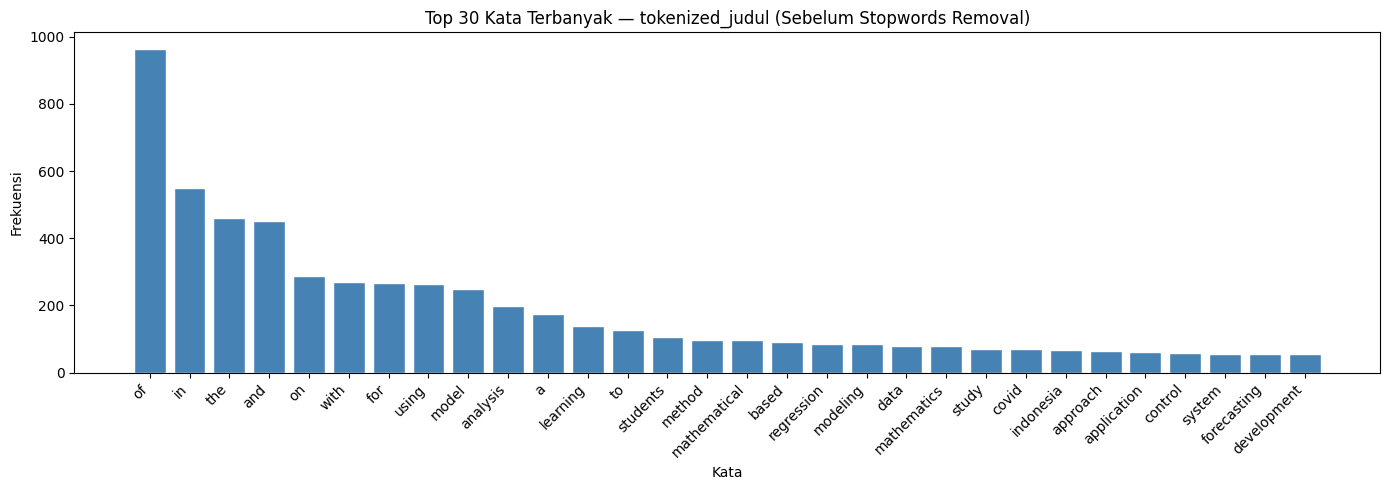

[tokenized_judul] Tokens: 15562 | Unique: 3474


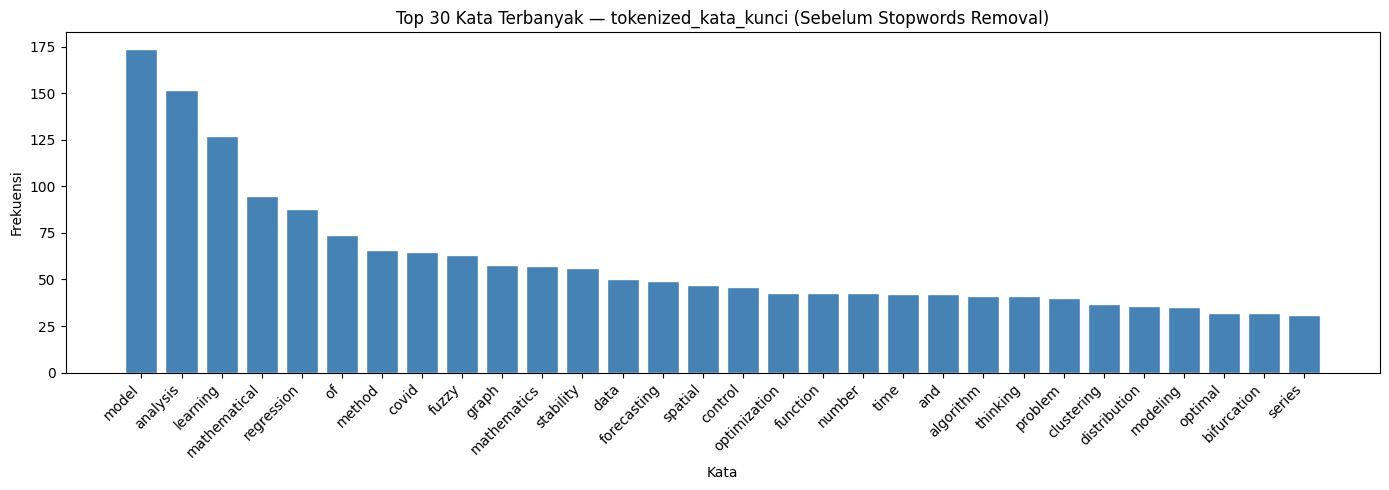

[tokenized_kata_kunci] Tokens: 9696 | Unique: 3216


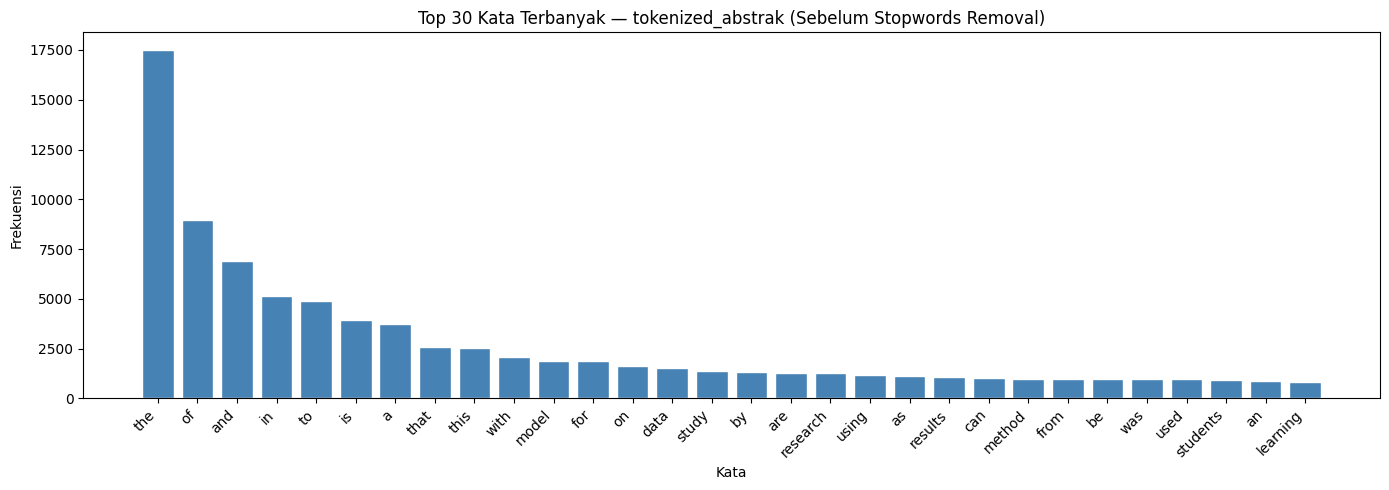

[tokenized_abstrak] Tokens: 218161 | Unique: 12421


In [18]:
from collections import Counter
import matplotlib.pyplot as plt

before_stopwords = df_manual_selected[["tokenized_judul", "tokenized_kata_kunci", "tokenized_abstrak"]]

for column in before_stopwords.columns:
    all_tokens   = [token for tokens in before_stopwords[column] for token in tokens]
    freq_count   = Counter(all_tokens)
    top_30       = freq_count.most_common(30)
    words, freqs = zip(*top_30)

    plt.figure(figsize=(14, 5))
    plt.bar(words, freqs, color='steelblue', edgecolor='white')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top 30 Kata Terbanyak — {column} (Sebelum Stopwords Removal)')
    plt.xlabel('Kata')
    plt.ylabel('Frekuensi')
    plt.tight_layout()
    plt.show()

    with open(f'freq_{column}_before_stopwords.txt', 'w') as f:
        f.write(f"Frekuensi Kata — {column} (Sebelum Stopwords Removal)\n")
        f.write(f"Total unique terms : {len(freq_count)}\n")
        f.write(f"Total tokens       : {len(all_tokens)}\n\n")
        f.write(f"{'No':<5} {'Kata':<30} {'Frekuensi'}\n")
        f.write("-" * 50 + "\n")
        for rank, (word, freq) in enumerate(freq_count.most_common(), 1):
            f.write(f"{rank:<5} {word:<30} {freq}\n")

    print(f"[{column}] Tokens: {len(all_tokens)} | Unique: {len(freq_count)}")

### Stopword Removal

In [19]:
stopwords = set(stopwords.words('english'))

custom_stopwords = {
    # ── Struktur Artikel ──────────────────────────────────────────────
    "research", "study", "paper", "papers", "article", "articles",
    "journal", "conference", "author", "authors",
    "work", "works", "literature", "existing", "previous", "current",
    "table", "figure", "section", "chapter", "review",
    "methodology", "methodologies", "methodological", 

    # ── Kata Kerja Umum ───────────────────────────────────────────────
    "use", "used", "using", "provide", "provides",
    "present", "presents", "show", "shows", "shown",
    "find", "finds", "finding", "findings",
    "discuss", "discusses", "discussed", "discussing",
    "contribute", "contributes", "contributed", "contributing",
    "apply", "applied", "applying",
    "compare", "compared", "comparison",
    "consider", "considered",
    "obtain", "obtained",
    "observe", "observed",
    "indicate", "indicates",
    "suggest", "suggests",
    "evaluate", "evaluation",
    "improve", "improvement", "conclude", "conclusion", "conclusions",

    # ── Metodologi Umum ───────────────────────────────────────────────
    "method", "methods", "approach", "technique", "techniques",
    "process", "processing", "framework",
    "proposed", "based", "new", "novel", "different",
    "experiment", "experiments", "experimental",
    "effect", "effects",

    # ── Data & Sistem ─────────────────────────────────────────────────
    "data", "dataset", "system", "systems",
    "application", "applications",
    "performance", "problem", "case", "cases",

    # ── Hasil & Kesimpulan ────────────────────────────────────────────
    "result", "results", "conclusion", "conclusions",
    "future", "aim", "additional", "future work", "future works",
    "additionaly", "potential", "challenge", "challenges", "opportunity", "opportunities",

    # ── Statistika Generik ────────────────────────────────────────────
    "statistic", "statistics",
    "estimate", "estimation",
    "sample", "variable", "variables",
    "parameter", "parameters",
    "value", "values",
    "set", "subset", "group", "groups","model", "models",

    # ── Tambahan ──────────────────────────────────────────────
    "number", "type", "types", "level", "levels",
    "large", "small", "high", "low", "well", "also",
    "however", "therefore", "thus", "hence", "moreover",
    "among", "within", "across", "toward", "via", "et", "al", "u", "p"
}

In [20]:
combination_stopwords = stopwords.union(custom_stopwords)
def stopwords_removal (tokens):
    return [word for word in tokens if word not in combination_stopwords]

In [21]:
df_manual_selected["stopwords_judul"] = df_manual_selected["tokenized_judul"].apply(stopwords_removal)
df_manual_selected["stopwords_kata_kunci"] = df_manual_selected["tokenized_kata_kunci"].apply(stopwords_removal)
df_manual_selected["stopwords_abstrak"] = df_manual_selected["tokenized_abstrak"].apply(stopwords_removal)

#### Display Stopword Removal

In [40]:
df_manual_selected["stop_judul"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["tokenized_judul"], row["stopwords_judul"]),
    axis=1
)
df_manual_selected["stop_keyword"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["tokenized_kata_kunci"], row["stopwords_kata_kunci"]),
    axis=1
)
df_manual_selected["stop_abstrak"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["tokenized_abstrak"], row["stopwords_abstrak"]),
    axis=1
) 

In [41]:
df_tampil_judul_stopwords = df_manual_selected[[
    "judul_artikel",
    "data_cleaning_judul",
    "case_folding_judul",
    "translate_judul",
    "tokenized_judul",
    "stopwords_judul",
    "stop_judul"
]].head(3)

In [42]:
df_tampil_keyword_stopwords = df_manual_selected[[
    "kata_kunci",
    "data_cleaning_kata_kunci",
    "case_folding_kata_kunci",
    "translate_keyword",
    "tokenized_kata_kunci",
    "stopwords_kata_kunci",
    "stop_keyword"
]].head(3)

In [43]:
df_tampil_abstrak_stopwords = df_manual_selected[[
    "abstrak",
    "data_cleaning_abstrak",
    "case_folding_abstrak",
    "translate_abstrak",
    "tokenized_abstrak",
    "stopwords_abstrak",
    "stop_abstrak"
]].head(5)

In [44]:
HTML(df_tampil_judul_stopwords.to_html(escape=False, index=False))

judul_artikel,data_cleaning_judul,case_folding_judul,translate_judul,tokenized_judul,stopwords_judul,stop_judul
"Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia",Drivers and Impacts of Agricultural Land Conversion Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies Indonesia,drivers and impacts of agricultural land conversion regression modelling with spatial dependence in west bandung and purwakarta regencies indonesia,drivers and impacts of agricultural land conversion regression modelling with spatial dependence in west bandung and purwakarta regencies indonesia,"[drivers, and, impacts, of, agricultural, land, conversion, regression, modelling, with, spatial, dependence, in, west, bandung, and, purwakarta, regencies, indonesia]","[drivers, impacts, agricultural, land, conversion, regression, modelling, spatial, dependence, west, bandung, purwakarta, regencies, indonesia]","['drivers', 'and', 'impacts', 'of', 'agricultural', 'land', 'conversion', 'regression', 'modelling', 'with', 'spatial', 'dependence', 'in', 'west', 'bandung', 'and', 'purwakarta', 'regencies', 'indonesia']"
Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder NPD Using Principal Component Analysis and the Naïve Bayes Model,feature selection analysis for diagnosing narcissistic personality disorder npd using principal component analysis and the naïve bayes model,feature selection analysis for diagnosing narcissistic personality disorder npd using principal component analysis and the naïve bayes model,"[feature, selection, analysis, for, diagnosing, narcissistic, personality, disorder, npd, using, principal, component, analysis, and, the, naïve, bayes, model]","[feature, selection, analysis, diagnosing, narcissistic, personality, disorder, npd, principal, component, analysis, naïve, bayes]","['feature', 'selection', 'analysis', 'for', 'diagnosing', 'narcissistic', 'personality', 'disorder', 'npd', 'using', 'principal', 'component', 'analysis', 'and', 'the', 'naïve', 'bayes', ^\n 'bayes'] ^\n 'model']"
Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency,Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data A Case Study of Tourism Workers in Malang Regency,zero inflated poisson regression for analyzing excess zeros in job transition data a case study of tourism workers in malang regency,zero inflated poisson regression for analyzing excess zeros in job transition data a case study of tourism workers in malang regency,"[zero, inflated, poisson, regression, for, analyzing, excess, zeros, in, job, transition, data, a, case, study, of, tourism, workers, in, malang, regency]","[zero, inflated, poisson, regression, analyzing, excess, zeros, job, transition, tourism, workers, malang, regency]","['zero', 'inflated', 'poisson', 'regression', 'for', 'analyzing', 'excess', 'zeros', 'in', 'job', 'transition', 'data', 'a', 'case', 'study', 'of', 'tourism', 'workers', 'in', 'malang', 'regency']"


In [45]:
HTML(df_tampil_keyword_stopwords.to_html(escape=False, index=False))

kata_kunci,data_cleaning_kata_kunci,case_folding_kata_kunci,translate_keyword,tokenized_kata_kunci,stopwords_kata_kunci,stop_keyword
Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,Agricultural Land Land Conversion Landowning Farmers Spatial Lag Model,agricultural land land conversion landowning farmers spatial lag model,agricultural land land conversion landowning farmers spatial lag model,"[agricultural, land, land, conversion, landowning, farmers, spatial, lag, model]","[agricultural, land, land, conversion, landowning, farmers, spatial, lag]","['agricultural', 'land', 'land', 'conversion', 'landowning', 'farmers', 'spatial', 'lag', ^\n 'lag'] ^\n 'model']"
Narcissistic Personality Disorder; Principal Component Analysis; Naïve Bayes; Feature Selection; Machine Learning.,Narcissistic Personality Disorder Principal Component Analysis Naïve Bayes Feature Selection Machine Learning,narcissistic personality disorder principal component analysis naïve bayes feature selection machine learning,narcissistic personality disorder principal component analysis naïve bayes feature selection machine learning,"[narcissistic, personality, disorder, principal, component, analysis, naïve, bayes, feature, selection, machine, learning]","[narcissistic, personality, disorder, principal, component, analysis, naïve, bayes, feature, selection, machine, learning]","['narcissistic', 'personality', 'disorder', 'principal', 'component', 'analysis', 'naïve', 'bayes', 'feature', 'selection', 'machine', 'learning']"
Count Data; Excess Zeros; Job Transitions; Tourism Industry; Zero-Inflated; Poisson,Count Data Excess Zeros Job Transitions Tourism Industry ZeroInflated Poisson,count data excess zeros job transitions tourism industry zeroinflated poisson,count data excess zeros job transitions tourism industry zeroinflated poisson,"[count, data, excess, zeros, job, transitions, tourism, industry, zeroinflated, poisson]","[count, excess, zeros, job, transitions, tourism, industry, zeroinflated, poisson]","['count', 'data', 'excess', 'zeros', 'job', 'transitions', 'tourism', 'industry', 'zeroinflated', 'poisson']"


In [46]:
HTML(df_tampil_abstrak_stopwords.to_html(escape=False, index=False))

In [47]:
for column in df_manual_selected[["stopwords_judul", "stopwords_kata_kunci", "stopwords_abstrak"]].columns:
    all_tokens   = [token for tokens in df_manual_selected[column] for token in tokens]
    freq_count   = Counter(all_tokens)
    with open(f'freq_{column}_after_stopwords.txt', 'w') as f:
        f.write(f"Frekuensi Kata — {column} (Setelah Stopwords Removal)\n")
        f.write(f"Total unique terms : {len(freq_count)}\n")
        f.write(f"Total tokens       : {len(all_tokens)}\n\n")
        f.write(f"{'No':<5} {'Kata':<30} {'Frekuensi'}\n")
        f.write("-" * 50 + "\n")
        for rank, (word, freq) in enumerate(freq_count.most_common(), 1):
            f.write(f"{rank:<5} {word:<30} {freq}\n")

    print(f"[{column}] Tokens: {len(all_tokens)} | Unique: {len(freq_count)}")


[stopwords_judul] Tokens: 10010 | Unique: 3347
[stopwords_kata_kunci] Tokens: 8762 | Unique: 3117
[stopwords_abstrak] Tokens: 109770 | Unique: 12151


### Lemmatization

In [22]:
lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(tag):
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def lemmatization(tokens):
    pos_tags = pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag))
            for word, tag in pos_tags]

In [23]:
df_manual_selected["lemmatized_judul"] = df_manual_selected["stopwords_judul"].apply(lemmatization)
df_manual_selected["lemmatized_kata_kunci"] = df_manual_selected["stopwords_kata_kunci"].apply(lemmatization)
df_manual_selected["lemmatized_abstrak"] = df_manual_selected["stopwords_abstrak"].apply(lemmatization) 

#### Display Lemmatization

In [50]:
df_manual_selected["lemma_judul"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["stopwords_judul"], row["lemmatized_judul"]),
    axis=1
)
df_manual_selected["lemma_kata_kunci"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["stopwords_kata_kunci"], row["lemmatized_kata_kunci"]),
    axis=1
)
df_manual_selected["lemma_abstrak"] = df_manual_selected.apply(
    lambda row: highlight_diff_clean(row["stopwords_abstrak"], row["lemmatized_abstrak"]),
    axis=1
) 

In [51]:
df_tampil_judul_lemma = df_manual_selected[[
    "judul_artikel",
    "data_cleaning_judul",
    "case_folding_judul",
    "translate_judul",
    "tokenized_judul",
    "stopwords_judul",
    "lemmatized_judul",
    "lemma_judul"
]].head(3)

In [52]:
df_tampil_keyword_lemma = df_manual_selected[[
    "kata_kunci",
    "data_cleaning_kata_kunci",
    "case_folding_kata_kunci",
    "translate_keyword",
    "tokenized_kata_kunci",
    "stopwords_kata_kunci",
    "lemmatized_kata_kunci",
    "lemma_kata_kunci"
]].head(3)

In [53]:
df_tampil_abstrak_lemma = df_manual_selected[[
    "abstrak",
    "data_cleaning_abstrak",
    "case_folding_abstrak",
    "translate_abstrak",
    "tokenized_abstrak",
    "stopwords_abstrak",
    "lemmatized_abstrak",
    "lemma_abstrak"
]].head(3)

In [54]:
HTML(df_tampil_judul_lemma.to_html(escape=False, index=False))

judul_artikel,data_cleaning_judul,case_folding_judul,translate_judul,tokenized_judul,stopwords_judul,lemmatized_judul,lemma_judul
"Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia",Drivers and Impacts of Agricultural Land Conversion Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies Indonesia,drivers and impacts of agricultural land conversion regression modelling with spatial dependence in west bandung and purwakarta regencies indonesia,drivers and impacts of agricultural land conversion regression modelling with spatial dependence in west bandung and purwakarta regencies indonesia,"[drivers, and, impacts, of, agricultural, land, conversion, regression, modelling, with, spatial, dependence, in, west, bandung, and, purwakarta, regencies, indonesia]","[drivers, impacts, agricultural, land, conversion, regression, modelling, spatial, dependence, west, bandung, purwakarta, regencies, indonesia]","[driver, impact, agricultural, land, conversion, regression, model, spatial, dependence, west, bandung, purwakarta, regency, indonesia]","['drivers', -\n ['driver', 'impacts', -\n 'impact', 'agricultural', 'land', 'conversion', 'regression', 'modelling', ----\n 'model', 'spatial', 'dependence', 'west', 'bandung', 'purwakarta', 'regencies', ^^^\n 'regency', ^\n 'indonesia']"
Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder NPD Using Principal Component Analysis and the Naïve Bayes Model,feature selection analysis for diagnosing narcissistic personality disorder npd using principal component analysis and the naïve bayes model,feature selection analysis for diagnosing narcissistic personality disorder npd using principal component analysis and the naïve bayes model,"[feature, selection, analysis, for, diagnosing, narcissistic, personality, disorder, npd, using, principal, component, analysis, and, the, naïve, bayes, model]","[feature, selection, analysis, diagnosing, narcissistic, personality, disorder, npd, principal, component, analysis, naïve, bayes]","[feature, selection, analysis, diagnose, narcissistic, personality, disorder, npd, principal, component, analysis, naïve, bayes]","['feature', 'selection', 'analysis', 'diagnosing', ^^^\n 'diagnose', ^\n 'narcissistic', 'personality', 'disorder', 'npd', 'principal', 'component', 'analysis', 'naïve', 'bayes']"
Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency,Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data A Case Study of Tourism Workers in Malang Regency,zero inflated poisson regression for analyzing excess zeros in job transition data a case study of tourism workers in malang regency,zero inflated poisson regression for analyzing excess zeros in job transition data a case study of tourism workers in malang regency,"[zero, inflated, poisson, regression, for, analyzing, excess, zeros, in, job, transition, data, a, case, study, of, tourism, workers, in, malang, regency]","[zero, inflated, poisson, regression, analyzing, excess, zeros, job, transition, tourism, workers, malang, regency]","[zero, inflate, poisson, regression, analyze, excess, zero, job, transition, tourism, worker, malang, regency]","['zero', 'inflated', -\n 'inflate', 'poisson', 'regression', 'analyzing', ^^^\n 'analyze', ^\n 'excess', 'zeros', -\n 'zero', 'job', 'transition', 'tourism', 'workers', -\n 'worker', 'malang', 'regency']"


In [55]:
HTML(df_tampil_keyword_lemma.to_html(escape=False, index=False))

kata_kunci,data_cleaning_kata_kunci,case_folding_kata_kunci,translate_keyword,tokenized_kata_kunci,stopwords_kata_kunci,lemmatized_kata_kunci,lemma_kata_kunci
Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,Agricultural Land Land Conversion Landowning Farmers Spatial Lag Model,agricultural land land conversion landowning farmers spatial lag model,agricultural land land conversion landowning farmers spatial lag model,"[agricultural, land, land, conversion, landowning, farmers, spatial, lag, model]","[agricultural, land, land, conversion, landowning, farmers, spatial, lag]","[agricultural, land, land, conversion, landowning, farmer, spatial, lag]","['agricultural', 'land', 'land', 'conversion', 'landowning', 'farmers', -\n 'farmer', 'spatial', 'lag']"
Narcissistic Personality Disorder; Principal Component Analysis; Naïve Bayes; Feature Selection; Machine Learning.,Narcissistic Personality Disorder Principal Component Analysis Naïve Bayes Feature Selection Machine Learning,narcissistic personality disorder principal component analysis naïve bayes feature selection machine learning,narcissistic personality disorder principal component analysis naïve bayes feature selection machine learning,"[narcissistic, personality, disorder, principal, component, analysis, naïve, bayes, feature, selection, machine, learning]","[narcissistic, personality, disorder, principal, component, analysis, naïve, bayes, feature, selection, machine, learning]","[narcissistic, personality, disorder, principal, component, analysis, naïve, bayes, feature, selection, machine, learning]","['narcissistic', 'personality', 'disorder', 'principal', 'component', 'analysis', 'naïve', 'bayes', 'feature', 'selection', 'machine', 'learning']"
Count Data; Excess Zeros; Job Transitions; Tourism Industry; Zero-Inflated; Poisson,Count Data Excess Zeros Job Transitions Tourism Industry ZeroInflated Poisson,count data excess zeros job transitions tourism industry zeroinflated poisson,count data excess zeros job transitions tourism industry zeroinflated poisson,"[count, data, excess, zeros, job, transitions, tourism, industry, zeroinflated, poisson]","[count, excess, zeros, job, transitions, tourism, industry, zeroinflated, poisson]","[count, excess, zeros, job, transition, tourism, industry, zeroinflated, poisson]","['count', 'excess', 'zeros', 'job', 'transitions', -\n 'transition', 'tourism', 'industry', 'zeroinflated', 'poisson']"


In [56]:
HTML(df_tampil_abstrak_lemma.to_html(escape=False, index=False))

In [24]:
df_manual_selected['lemmatized_judul']       = df_manual_selected['lemmatized_judul'].apply(lambda tokens: ' '.join(tokens))
df_manual_selected['lemmatized_kata_kunci']  = df_manual_selected['lemmatized_kata_kunci'].apply(lambda tokens: ' '.join(tokens))
df_manual_selected['lemmatized_abstrak']     = df_manual_selected['lemmatized_abstrak'].apply(lambda tokens: ' '.join(tokens))

## Feature Extraction

In [25]:
df_manual_selected['combined'] = df_manual_selected['lemmatized_judul'] + ' ' + df_manual_selected['lemmatized_kata_kunci'] + ' ' + df_manual_selected['lemmatized_abstrak']

In [26]:
tfidf_vectorizer = TfidfVectorizer(
  max_features=10000,
  ngram_range=(1, 2),
  min_df=2,
  max_df=0.95,
  sublinear_tf=False,
  norm=None,
  stop_words='english'
)

In [27]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df_manual_selected['combined'])

#### Manual TF-IDF Counting

In [28]:
# ── DEFINISI FUNGSI ───────────────────────────────────────────────────────────
def show_full_tfidf_table(df, tfidf_vectorizer, tfidf_matrix, indices=None):
    """
    Cetak tabel TF, IDF, TF-IDF setiap kata terhadap dokumen
    indices: list index dokumen yang ingin dicetak
    """
    feature_names = tfidf_vectorizer.get_feature_names_out()
    idf_all       = tfidf_vectorizer.idf_
    dense         = tfidf_matrix.toarray()

    if indices is None:
        indices = list(range(5)) + [-1]  

    for i in indices:
        doc_id = df['id_document'].iloc[i]
        print(f"\n{'='*60}")
        print(f"Dokumen : {doc_id}")
        print(f"{'='*60}")

        tf_doc = np.divide(dense[i], idf_all,
                           out=np.zeros_like(dense[i]),
                           where=idf_all != 0)

        rows = []
        for j, term in enumerate(feature_names):
            if dense[i][j] > 0:
                rows.append({
                    'No'     : len(rows) + 1,
                    'Term'   : term,
                    'TF'     : round(tf_doc[j],   6),
                    'IDF'    : round(idf_all[j],  6),
                    'TF-IDF' : round(dense[i][j], 6),
                })

        print(f"Total term aktif : {len(rows)}")
        print(tabulate(rows, headers='keys', tablefmt='grid',
                       showindex=False, floatfmt='.6f'))

# ── FIT TF-IDF ────────────────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    ngram_range  = (1, 3),
    max_df       = 0.95,
    min_df       = 2,
    max_features = 10000,
    sublinear_tf = False,
    norm         = None
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_manual_selected['combined'])
print(f"Shape TF-IDF Matrix : {tfidf_matrix.shape}")

show_full_tfidf_table(
    df               = df_manual_selected,
    tfidf_vectorizer = tfidf_vectorizer,
    tfidf_matrix     = tfidf_matrix,
    indices          = list(range(5)) + [-1]
)

Shape TF-IDF Matrix : (1164, 10000)

Dokumen : doc1
Total term aktif : 75
+------+----------------------------+----------+----------+-----------+
|   No | Term                       |       TF |      IDF |    TF-IDF |
+======+============================+==========+==========+===========+
|    1 | affect                     | 1.000000 | 3.192942 |  3.192942 |
+------+----------------------------+----------+----------+-----------+
|    2 | agricultural               | 2.000000 | 5.227263 | 10.454526 |
+------+----------------------------+----------+----------+-----------+
|    3 | agricultural land          | 2.000000 | 6.674182 | 13.348364 |
+------+----------------------------+----------+----------+-----------+
|    4 | assess                     | 1.000000 | 3.653757 |  3.653757 |
+------+----------------------------+----------+----------+-----------+
|    5 | balance                    | 1.000000 | 4.449558 |  4.449558 |
+------+----------------------------+----------+----------+---

In [29]:
# ── CEK RUMUS TF-IDF SKLEARN ──────────────────────────────────────────────────
print("Parameter TF-IDF Vectorizer:")
print(f"  norm         : {tfidf_vectorizer.norm}")
print(f"  sublinear_tf : {tfidf_vectorizer.sublinear_tf}")
print(f"  smooth_idf   : {tfidf_vectorizer.smooth_idf}")
print(f"  use_idf      : {tfidf_vectorizer.use_idf}")

print("\nRumus yang digunakan:")

# TF
if tfidf_vectorizer.sublinear_tf:
    print("  TF  : 1 + log(f(t,d))  ← sublinear_tf=True")
else:
    print("  TF  : count(t,d)  ← sublinear_tf=False")

# IDF
if tfidf_vectorizer.smooth_idf:
    print("  IDF : ln((N+1)/(df_t+1)) + 1  ← smooth_idf=True (default sklearn)")
else:
    print("  IDF : ln(N/df_t) + 1  ← smooth_idf=False")

# Normalisasi
if tfidf_vectorizer.norm == 'l2':
    print("  Norm: L2 normalization  ← norm='l2'")
elif tfidf_vectorizer.norm is None:
    print("  Norm: Tidak ada normalisasi  ← norm=None")

Parameter TF-IDF Vectorizer:
  norm         : None
  sublinear_tf : False
  smooth_idf   : True
  use_idf      : True

Rumus yang digunakan:
  TF  : count(t,d)  ← sublinear_tf=False
  IDF : ln((N+1)/(df_t+1)) + 1  ← smooth_idf=True (default sklearn)
  Norm: Tidak ada normalisasi  ← norm=None


#### Manual TF-IDF By Term 

In [30]:
def identify_tfidf_one_term(term, df, tfidf_vectorizer, tfidf_matrix):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    idf_all       = tfidf_vectorizer.idf_
    dense         = tfidf_matrix.toarray()
    N             = len(df)

    if term not in feature_names:
        print(f"Term '{term}' tidak ada di vocabulary.")
        return

    term_idx = list(feature_names).index(term)
    idf_val  = idf_all[term_idx]
    df_t     = round((N + 1) / np.exp(idf_val - 1) - 1)

    print(f"{'='*60}")
    print(f"Term     : '{term}'")
    print(f"N        : {N}")
    print(f"df(t)    : {df_t}")
    print(f"IDF      : ln(({N}+1)/({df_t}+1)) + 1 = {idf_val:.6f}")
    print(f"{'='*60}")

    rows = []
    for i, doc_id in enumerate(df['id_document']):
        tfidf_val = dense[i][term_idx]
        if tfidf_val > 0:
            tf_all_doc  = np.divide(dense[i], idf_all,
                                    out=np.zeros_like(dense[i]),
                                    where=idf_all != 0)
            total_terms = tf_all_doc.sum()

            doc_tokens = df['combined'].iloc[i].split()
            if ' ' in term:
                w1, w2 = term.split()
                freq = sum(1 for a, b in zip(doc_tokens, doc_tokens[1:])
                           if a == w1 and b == w2)
            else:
                freq = doc_tokens.count(term)

            tf_val = tfidf_val / idf_val if idf_val > 0 else 0

            rows.append({
                'No'          : len(rows) + 1,
                'Dokumen'     : doc_id,
                f'f("{term}")': freq,
                'Total Term'  : round(total_terms, 4),
                'TF'          : round(tf_val,    4),
                'IDF Formula' : f"ln(({N}+1)/({df_t}+1))+1",
                'IDF'         : round(idf_val,   4),
                'TF-IDF'      : round(tfidf_val, 4),
            })

    print(f"Dokumen mengandung '{term}' : {len(rows)}\n")
    print(tabulate(rows, headers='keys', tablefmt='grid',
                   showindex=False, floatfmt='.4f'))
    return pd.DataFrame(rows)

# ── EKSEKUSI ──────────────────────────────────────────────────────────────────
term_input = input("Masukkan term: ")
identify_tfidf_one_term(term_input, df_manual_selected, tfidf_vectorizer, tfidf_matrix)

Term     : 'classification'
N        : 1164
df(t)    : 66
IDF      : ln((1164+1)/(66+1)) + 1 = 3.855784
Dokumen mengandung 'classification' : 66

+------+-----------+-----------------------+--------------+---------+-----------------------+--------+----------+
|   No | Dokumen   |   f("classification") |   Total Term |      TF | IDF Formula           |    IDF |   TF-IDF |
+======+===========+=======================+==============+=========+=======================+========+==========+
|    1 | doc2      |                     2 |     161.0000 |  2.0000 | ln((1164+1)/(66+1))+1 | 3.8558 |   7.7116 |
+------+-----------+-----------------------+--------------+---------+-----------------------+--------+----------+
|    2 | doc8      |                     1 |     151.0000 |  1.0000 | ln((1164+1)/(66+1))+1 | 3.8558 |   3.8558 |
+------+-----------+-----------------------+--------------+---------+-----------------------+--------+----------+
|    3 | doc26     |                     1 |     105.000

,No,Dokumen,"f(""classification"")",Total Term,TF,IDF Formula,IDF,TF-IDF
0,1,doc2,2,161.0,2.0,ln((1164+1)/(66+1))+1,3.8558,7.7116
1,2,doc8,1,151.0,1.0,ln((1164+1)/(66+1))+1,3.8558,3.8558
2,3,doc26,1,105.0,1.0,ln((1164+1)/(66+1))+1,3.8558,3.8558
3,4,doc46,1,74.0,1.0,ln((1164+1)/(66+1))+1,3.8558,3.8558
4,5,doc58,9,152.0,9.0,ln((1164+1)/(66+1))+1,3.8558,34.7021
...,...,...,...,...,...,...,...,...
61,62,doc1002,3,125.0,3.0,ln((1164+1)/(66+1))+1,3.8558,11.5674
62,63,doc1004,2,127.0,2.0,ln((1164+1)/(66+1))+1,3.8558,7.7116
63,64,doc1011,2,218.0,2.0,ln((1164+1)/(66+1))+1,3.8558,7.7116
64,65,doc1043,2,166.0,2.0,ln((1164+1)/(66+1))+1,3.8558,7.7116


#### TF-IDF Matrix

In [31]:
def show_tfidf_matrix_sorted(df, tfidf_vectorizer, tfidf_matrix):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    dense         = tfidf_matrix.toarray()

    # Term aktif di dokumen pertama → urutkan alfabetis → 5 awal + 1 akhir
    active_idx   = np.where(dense[0] > 0)[0]
    active_terms = feature_names[active_idx]
    sorted_order = np.argsort(active_terms)
    sorted_idx   = active_idx[sorted_order]
    sorted_terms = feature_names[sorted_idx]

    # 5 term awal + 1 akhir
    term_idx   = list(sorted_idx[:5]) + [sorted_idx[-1]]
    term_labels = [f"W({t},doc_i)" for t in sorted_terms[:5]] + \
                  [f"W({sorted_terms[-1]},doc_i)"]

    # Sisipkan 'classification' di tengah jika ada di vocabulary
    if 'classification' in feature_names:
        cls_idx   = list(feature_names).index('classification')
        mid       = len(term_idx) // 2
        term_idx.insert(mid, cls_idx)
        term_labels.insert(mid, "W(classification,doc_i)")
    else:
        print(" 'classification' tidak ada di vocabulary.")

    # 5 dokumen awal + 1 terakhir
    doc_idx    = list(range(5)) + [-1]
    doc_labels = [f"doc_{i+1}" for i in range(5)] + [f"doc_{len(df)}"]

    # Bangun tabel
    result = pd.DataFrame(
        dense[np.ix_(doc_idx, term_idx)].round(4),
        index   = doc_labels,
        columns = term_labels
    )
    result.index.name = 'Dokumen'

    print("Tabel Bobot TF-IDF:")
    print(tabulate(result, headers='keys', tablefmt='grid', floatfmt='.4f'))
    return result

# ── EKSEKUSI ──────────────────────────────────────────────────────────────────
show_tfidf_matrix_sorted(df_manual_selected, tfidf_vectorizer, tfidf_matrix)

Tabel Bobot TF-IDF:
+-----------+-------------------+-------------------------+------------------------------+---------------------------+-------------------+--------------------+----------------------+
| Dokumen   |   W(affect,doc_i) |   W(agricultural,doc_i) |   W(agricultural land,doc_i) |   W(classification,doc_i) |   W(assess,doc_i) |   W(balance,doc_i) |   W(west java,doc_i) |
+===========+===================+=========================+==============================+===========================+===================+====================+======================+
| doc_1     |            3.1929 |                 10.4545 |                      13.3484 |                    0.0000 |            3.6538 |             4.4496 |               4.9250 |
+-----------+-------------------+-------------------------+------------------------------+---------------------------+-------------------+--------------------+----------------------+
| doc_2     |            3.1929 |                  0.0000 |      

,"W(affect,doc_i)","W(agricultural,doc_i)","W(agricultural land,doc_i)","W(classification,doc_i)","W(assess,doc_i)","W(balance,doc_i)","W(west java,doc_i)"
Dokumen,,,,,,,
doc_1,3.1929,10.4545,13.3484,0.0000,3.6538,4.4496,4.925
doc_2,3.1929,0.0000,0.0000,7.7116,0.0000,0.0000,0.000
doc_3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000
doc_4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000
doc_5,0.0000,5.2273,0.0000,0.0000,0.0000,0.0000,0.000
doc_1164,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000


In [32]:
print(f"Shape TF-IDF Matrix : {tfidf_matrix.shape}")
print(f"Jumlah Dokumen      : {tfidf_matrix.shape[0]}")
print(f"Jumlah Fitur        : {tfidf_matrix.shape[1]}")
print(f"Jumlah Fitur (Vector) : {len(tfidf_vectorizer.get_feature_names_out())}")

Shape TF-IDF Matrix : (1164, 10000)
Jumlah Dokumen      : 1164
Jumlah Fitur        : 10000
Jumlah Fitur (Vector) : 10000


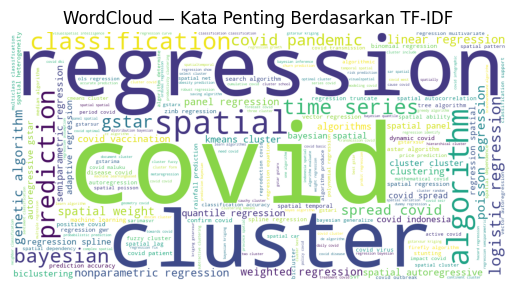

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

custom_stopwords_wr = [
    'analysis','data','system','study','result','paper','method',
    'using','based','approach','model','research','case'
]

keywords_focus_wr = [
    'covid','stunting','regression','cluster','classification',
    'prediction','algorithm','time series','spatial','gstar',
    'bayesian','svr','machine learning'
]

vectorizer_wr = TfidfVectorizer(
    stop_words=custom_stopwords_wr,
    ngram_range=(1,2)  # biar "time series" kebaca
)

tfidf_matrix_wr = vectorizer_wr.fit_transform(df_manual_selected['combined'])
terms_wr = vectorizer_wr.get_feature_names_out()

# 3. ambil bobot
weights_wr = np.array(tfidf_matrix_wr.sum(axis=0)).flatten()

# 4. filter hanya kata penting
filtered_freq = {
    term: weight for term, weight in zip(terms_wr, weights_wr)
    if any(k in term for k in keywords_focus_wr)
}

# 5. wordcloud
wc = WordCloud(width=1000, height=500, background_color='white')
wc.generate_from_frequencies(filtered_freq)

plt.imshow(wc)
plt.axis('off')
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

custom_stopwords_wr= [
    'analysis','data','system','study','result','paper','method',
    'using','based','approach','model','research','case'
]

keywords_focus_wr = [
    'covid','stunting','regression','cluster','classification',
    'prediction','algorithm','time series','spatial','gstar',
    'bayesian','svr','machine learning'
]

vectorizer_wr = TfidfVectorizer(
    stop_words=custom_stopwords_wr,
    ngram_range=(1,2) 
)

tfidf_matrix_wr = vectorizer_wr.fit_transform(df_manual_selected['combined'])
terms_wr = vectorizer_wr.get_feature_names_out()

# 3. ambil bobot
weights_wr = np.array(tfidf_matrix_wr.sum(axis=0)).flatten()

# 4. filter hanya kata penting
filtered_freq = {
    term: weight for term, weight in zip(terms_wr, weights_wr)
    if any(k in term for k in keywords_focus_wr)
}

# 5. wordcloud
wc = WordCloud(width=1000, height=500, background_color='white')
wc.generate_from_frequencies(filtered_freq)

plt.imshow(wc)
plt.axis('off')
plt.title("WordCloud — Kata Penting Berdasarkan TF-IDF")
plt.show()
plt.show()

## Cosine Similarity

In [34]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Shape Cosine Similarity Matrix : {cosine_sim.shape}")

Shape Cosine Similarity Matrix : (1164, 1164)


In [35]:
print(cosine_sim.round(4))

[[1.     0.0046 0.0153 ... 0.0072 0.0831 0.0132]
 [0.0046 1.     0.0063 ... 0.0124 0.006  0.0023]
 [0.0153 0.0063 1.     ... 0.0146 0.0109 0.0491]
 ...
 [0.0072 0.0124 0.0146 ... 1.     0.013  0.0894]
 [0.0831 0.006  0.0109 ... 0.013  1.     0.    ]
 [0.0132 0.0023 0.0491 ... 0.0894 0.     1.    ]]


In [36]:
print("Rata-rata:", np.mean(cosine_sim))
print("Median:", np.median(cosine_sim))
print("Quartiles:", np.percentile(cosine_sim, [25, 50, 75]))
print("Standar deviasi:", np.std(cosine_sim))
print("Nilai minimum:", np.min(cosine_sim))
print("Nilai maksimum:", np.max(cosine_sim))

Rata-rata: 0.017450795328912982
Median: 0.00695734115089236
Quartiles: [0.00251949 0.00695734 0.01618289]
Standar deviasi: 0.04366355769398564
Nilai minimum: 0.0
Nilai maksimum: 1.0000000000000027


#### Manual Cosine Similarity

In [37]:
def show_cosine_step_by_step(doc_num_1, doc_num_2, df, tfidf_matrix, cosine_sim):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    dense         = tfidf_matrix.toarray()

    doc_id_1 = f"doc{doc_num_1}"
    doc_id_2 = f"doc{doc_num_2}"

    idx_1 = df.index[df['id_document'] == doc_id_1].tolist()
    idx_2 = df.index[df['id_document'] == doc_id_2].tolist()

    if not idx_1:
        print(f"Dokumen '{doc_id_1}' tidak ditemukan."); return
    if not idx_2:
        print(f"Dokumen '{doc_id_2}' tidak ditemukan."); return

    idx_1 = idx_1[0]
    idx_2 = idx_2[0]
    vec_a = dense[idx_1]
    vec_b = dense[idx_2]

    print(f"{'='*65}")
    print(f"Dokumen A : {doc_id_1}")
    print(f"Judul     : {df.loc[idx_1, 'judul_artikel']}")
    print(f"Dokumen B : {doc_id_2}")
    print(f"Judul     : {df.loc[idx_2, 'judul_artikel']}")
    print(f"{'='*65}")

    # ── RUMUS ─────────────────────────────────────────────────────────
    print(f"\n── Rumus ────────────────────────────────────────────────────")
    print(f"           Σ(W_{{t,A}} × W_{{t,B}})")
    print(f"Sim(A,B) = ─────────────────────────────────────────────────")
    print(f"           √(Σ W²_{{t,A}}) × √(Σ W²_{{t,B}})")

    # ── TERM AKTIF & DIMENSI VEKTOR ───────────────────────────────────
    active_both = np.where((vec_a > 0) & (vec_b > 0))[0]
    active_a    = np.where(vec_a > 0)[0]
    active_b    = np.where(vec_b > 0)[0]

    print(f"\n── Info Term & Dimensi Vektor ───────────────────────────────")
    # Bagian baru untuk menampilkan total dimensi vektor asli (jumlah seluruh kata unik)
    print(f"Dimensi Vektor Dokumen A ({doc_id_1}) : {len(vec_a)} kolom (total kosakata corpus)")
    print(f"Dimensi Vektor Dokumen B ({doc_id_2}) : {len(vec_b)} kolom (total kosakata corpus)")
    print(f"-"*45)
    print(f"Term aktif di {doc_id_1} (nilai TF-IDF > 0) : {len(active_a)} term")
    print(f"Term aktif di {doc_id_2} (nilai TF-IDF > 0) : {len(active_b)} term")
    print(f"Term aktif BERSAMA                      : {len(active_both)} term")

    # ── STEP 1: TABEL SELURUH TERM AKTIF BERSAMA ─────────────────────
    print(f"\n── Step 1: Seluruh Term Aktif Bersama ({len(active_both)} term) ──")
    if len(active_both) > 0:
        dot_rows = [{'Term'              : feature_names[j],
                     f'W(t,{doc_id_1})' : round(vec_a[j], 4),
                     f'W(t,{doc_id_2})' : round(vec_b[j], 4),
                     'W_A × W_B'        : round(vec_a[j]*vec_b[j], 4)}
                    for j in active_both]
        print(tabulate(dot_rows, headers='keys', tablefmt='grid',
                       showindex=False, floatfmt='.4f'))
    else:
        print("Tidak ada term yang sama → Dot Product = 0")

    # ── STEP 2: PEMBILANG ─────────────────────────────────────────────
    dot = np.dot(vec_a, vec_b)
    print(f"\n── Step 2: Pembilang (Dot Product) t=1 hingga t={len(active_both)} ──")
    if len(active_both) > 0:
        dot_manual = []
        cumsum_dot = 0
        for rank, j in enumerate(active_both, 1):
            prod       = vec_a[j] * vec_b[j]
            cumsum_dot += prod
            dot_manual.append({
                't'                 : rank,
                'Term'              : feature_names[j],
                f'W(t,{doc_id_1})' : round(vec_a[j],    4),
                f'W(t,{doc_id_2})' : round(vec_b[j],    4),
                'W_A × W_B'        : round(prod,         4),
                'Σ kumulatif'       : round(cumsum_dot,  4),
            })
        print(tabulate(dot_manual, headers='keys', tablefmt='grid',
                       showindex=False, floatfmt='.4f'))
        print(f"\nTotal A·B = {dot:.4f}")

    # ── STEP 3: PENYEBUT NORM A ───────────────────────────────────────
    sum_sq_a = np.sum(vec_a**2)
    norm_a   = np.sqrt(sum_sq_a)
    print(f"\n── Step 3: Penyebut — Norm {doc_id_1} (t=1 hingga t={len(active_a)}) ──")
    norm_a_rows = []
    cumsum_sq_a = 0
    for rank, j in enumerate(active_a, 1):
        sq          = vec_a[j]**2
        cumsum_sq_a += sq
        norm_a_rows.append({
            't'             : rank,
            'Term'          : feature_names[j],
            'W'             : round(vec_a[j], 4),
            'W²'            : round(sq,       4),
            'Σ W² kumulatif': round(cumsum_sq_a, 4),
        })
    print(tabulate(norm_a_rows, headers='keys', tablefmt='grid',
                   showindex=False, floatfmt='.4f'))
    print(f"\n||{doc_id_1}|| = √{sum_sq_a:.4f} = {norm_a:.4f}")

    # ── STEP 3: PENYEBUT NORM B ───────────────────────────────────────
    sum_sq_b = np.sum(vec_b**2)
    norm_b   = np.sqrt(sum_sq_b)
    print(f"\n── Step 3: Penyebut — Norm {doc_id_2} (t=1 hingga t={len(active_b)}) ──")
    norm_b_rows = []
    cumsum_sq_b = 0
    for rank, j in enumerate(active_b, 1):
        sq          = vec_b[j]**2
        cumsum_sq_b += sq
        norm_b_rows.append({
            't'             : rank,
            'Term'          : feature_names[j],
            'W'             : round(vec_b[j], 4),
            'W²'            : round(sq,       4),
            'Σ W² kumulatif': round(cumsum_sq_b, 4),
        })
    print(tabulate(norm_b_rows, headers='keys', tablefmt='grid',
                   showindex=False, floatfmt='.4f'))
    print(f"\n||{doc_id_2}|| = √{sum_sq_b:.4f} = {norm_b:.4f}")

    denom = norm_a * norm_b
    print(f"\n||{doc_id_1}|| × ||{doc_id_2}||")
    print(f"= {norm_a:.4f} × {norm_b:.4f}")
    print(f"= {denom:.4f}")

    # ── STEP 4: COSINE SIMILARITY ─────────────────────────────────────
    score  = dot / denom if denom > 0 else 0.0
    sk_val = cosine_sim[idx_1][idx_2]

    print(f"\n── Step 4: Cosine Similarity ────────────────────────────────")
    print(f"Sim({doc_id_1},{doc_id_2})")
    print(f"= {dot:.4f} / {denom:.4f}")
    print(f"= {score:.4f}")
    print(f"\nValidasi Sklearn : {sk_val:.4f}")
    print(f"Identik?         : {'✓ VALID' if np.isclose(score, sk_val) else '✗ BERBEDA'}")
    print(f"{'='*65}")
# ── MENGAMBIL 2 ANGKA AWAL DAN 1 ANGKA AKHIR ─────────────────────
    print(f"\n── Cek Nilai Ujung Vektor {doc_id_1} ────────────────────────")
    
    # Slicing array NumPy
    dua_awal       = vec_a[:2]
    satu_akhir     = vec_a[-1:] # Mengambil dalam bentuk array agar konsisten
    
    # Ambil nama term/kata yang bersesuaian untuk konteks
    term_awal      = feature_names[:2]
    term_akhir     = feature_names[-1:]

    # Tampilkan 2 angka awal
    print("2 Angka Awal di Vektor:")
    for i in range(2):
        print(f"  Indeks [{i}] - Term '{term_awal[i]}': {dua_awal[i]:.4f}")
        
    # Tampilkan 1 angka akhir
    print("\n1 Angka Akhir di Vektor:")
    print(f"  Indeks [{len(vec_a)-1}] - Term '{term_akhir[0]}': {satu_akhir[0]:.4f}")
    print(f"-"*45)
# ── EKSEKUSI ──────────────────────────────────────────────────────────────────
doc_num_1 = int(input("Masukkan nomor dokumen pertama : "))
doc_num_2 = int(input("Masukkan nomor dokumen kedua   : "))
show_cosine_step_by_step(doc_num_1, doc_num_2, df_manual_selected, tfidf_matrix, cosine_sim)

Dokumen A : doc6
Judul     : Evaluating Robust Estimators in Geographically Weighted Regression for Stunting Analysis at the District-Level Across Java: A Focus on Outlier Handling
Dokumen B : doc791
Judul     : Mathematical Modeling of Stunting with the Influence of Nutritional Intervention

── Rumus ────────────────────────────────────────────────────
           Σ(W_{t,A} × W_{t,B})
Sim(A,B) = ─────────────────────────────────────────────────
           √(Σ W²_{t,A}) × √(Σ W²_{t,B})

── Info Term & Dimensi Vektor ───────────────────────────────
Dimensi Vektor Dokumen A (doc6) : 10000 kolom (total kosakata corpus)
Dimensi Vektor Dokumen B (doc791) : 10000 kolom (total kosakata corpus)
---------------------------------------------
Term aktif di doc6 (nilai TF-IDF > 0) : 89 term
Term aktif di doc791 (nilai TF-IDF > 0) : 92 term
Term aktif BERSAMA                      : 18 term

── Step 1: Seluruh Term Aktif Bersama (18 term) ──
+------------------+-------------+---------------+---------

Dokumen A : doc6
Judul     : Evaluating Robust Estimators in Geographically Weighted Regression for Stunting Analysis at the District-Level Across Java: A Focus on Outlier Handling
--------------------------------------------------------------------------------
Dokumen B : doc791
Judul     : Mathematical Modeling of Stunting with the Influence of Nutritional Intervention

Cosine Similarity = 0.4502
Tingkat kemiripan = 45.02%

Jumlah kata yang sama : 18

20 Kata Sama dengan Bobot TF-IDF Terbesar
            Kata  Bobot_TFIDF
           stunt    67.950973
      prevalence    25.090064
    intervention    24.428954
         toddler    20.521381
prevalence stunt    12.902077
        stunting     8.971552
            risk     8.540214
          target     6.520356
 influence stunt     6.451038
          reduce     6.355349
          handle     6.252984
       influence     5.837626
         program     5.499041
          impact     4.678251
           early     4.371597
       reduction    

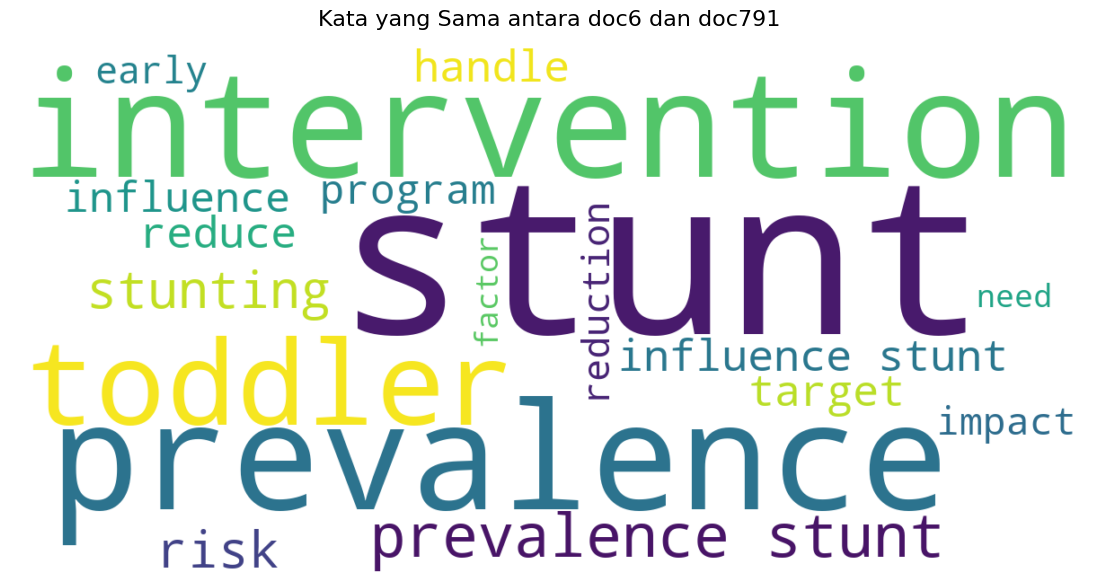

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def show_cosine_step_by_step(doc_num_1, doc_num_2, df, tfidf_matrix, cosine_sim):

    feature_names = tfidf_vectorizer.get_feature_names_out()
    dense = tfidf_matrix.toarray()

    doc_id_1 = f"doc{doc_num_1}"
    doc_id_2 = f"doc{doc_num_2}"

    idx_1 = df.index[df['id_document'] == doc_id_1].tolist()
    idx_2 = df.index[df['id_document'] == doc_id_2].tolist()

    if not idx_1:
        print(f"Dokumen '{doc_id_1}' tidak ditemukan.")
        return

    if not idx_2:
        print(f"Dokumen '{doc_id_2}' tidak ditemukan.")
        return

    idx_1 = idx_1[0]
    idx_2 = idx_2[0]

    vec_a = dense[idx_1]
    vec_b = dense[idx_2]

    print("="*80)
    print(f"Dokumen A : {doc_id_1}")
    print(f"Judul     : {df.loc[idx_1, 'judul_artikel']}")
    print("-"*80)
    print(f"Dokumen B : {doc_id_2}")
    print(f"Judul     : {df.loc[idx_2, 'judul_artikel']}")
    print("="*80)

    # ======================================================
    # COSINE SIMILARITY MANUAL
    # ======================================================

    dot_product = np.dot(vec_a, vec_b)

    norm_a = np.sqrt(np.sum(vec_a**2))
    norm_b = np.sqrt(np.sum(vec_b**2))

    cosine_score = dot_product / (norm_a * norm_b)

    print(f"\nCosine Similarity = {cosine_score:.4f}")
    print(f"Tingkat kemiripan = {cosine_score*100:.2f}%")

    # ======================================================
    # KATA YANG MUNCUL PADA KEDUA DOKUMEN
    # ======================================================

    common_idx = (vec_a > 0) & (vec_b > 0)

    common_words = feature_names[common_idx]

    common_weights = (
        vec_a[common_idx] + vec_b[common_idx]
    ) / 2

    if len(common_words) == 0:
        print("\nTidak ditemukan kata yang sama.")
        return

    common_df = pd.DataFrame({
        'Kata': common_words,
        'Bobot_TFIDF': common_weights
    })

    common_df = common_df.sort_values(
        by='Bobot_TFIDF',
        ascending=False
    )

    print("\nJumlah kata yang sama :", len(common_df))

    print("\n20 Kata Sama dengan Bobot TF-IDF Terbesar")
    print(common_df.head(20).to_string(index=False))

    # ======================================================
    # WORD CLOUD KATA YANG SAMA SAJA
    # ======================================================

    freq = dict(
        zip(
            common_df['Kata'],
            common_df['Bobot_TFIDF']
        )
    )

    wc = WordCloud(
        width=1200,
        height=600,
        background_color='white'
    )

    wc.generate_from_frequencies(freq)

    plt.figure(figsize=(14,7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(
        f"Kemiripan Antara {doc_id_1} dan {doc_id_2}",
        fontsize=16
    )
    plt.show()


# ==========================================================
# EKSEKUSI
# ==========================================================

doc_num_1 = int(input("Masukkan nomor Dokumen A: "))
doc_num_2 = int(input("Masukkan nomor Dokumen B: "))

show_cosine_step_by_step(
    doc_num_1,
    doc_num_2,
    df_manual_selected,
    tfidf_matrix,
    cosine_sim
)

## Evaluation

### Define sample size

In [72]:
N = 1164
e = 0.05
n_sample = int(round(N / (1 + N * e**2)))
print(f"Jumlah sampel yang dibutuhkan: {round(n_sample)}")

Jumlah sampel yang dibutuhkan: 298


In [73]:
df_final = df_manual_selected.reset_index(drop=True)

In [74]:
np.random.seed(89)
query_indices = np.random.choice(df_final.index, n_sample, replace=False)
print(f"\n{'='*30} DAFTAR SAMPEL QUERY {'='*30}")
df_query_list = df_final.iloc[query_indices][['id_document', 'judul_artikel']].head(10)
print(tabulate(df_query_list, headers='keys', tablefmt='fancy_grid', showindex=True))


============================== DAFTAR SAMPEL QUERY ==============================
╒═════╤═══════════════╤═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│     │ id_document   │ judul_artikel                                                                                                                         │
╞═════╪═══════════════╪═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│   2 │ doc3          │ Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency │
├─────┼───────────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│  65 │ doc66         │ RELATIVE RISK ANALYSIS OF THE SPREAD OF COVID-19 VIRUS IN MEDAN CITY BY SPATIAL AND NON-SPATI

In [ ]:
thresholds = [round(x, 1) for x in np.arange(0.0, 0.9, 0.1)]
summary_rows = []

print(f"\nMenghitung evaluasi untuk {n_sample} query terhadap {N} dokumen...")

for k in [5, 10, 15, 20]:
    for thr in thresholds:
        p_list, r_list = [], []

        for q_idx in query_indices:
            sim_scores = cosine_sim[q_idx]
            
            relevant_indices = np.where(sim_scores >= thr)[0]
            relevant_indices = relevant_indices[relevant_indices != q_idx]
            
            if len(relevant_indices) == 0:
                continue
            ranked_indices = np.argsort(sim_scores)[::-1][1 : k+1]
            
            hits = len(set(ranked_indices) & set(relevant_indices))

            p_list.append(hits / k)
            r_list.append(hits / len(relevant_indices))

        if p_list:
            mean_p = np.mean(p_list)
            mean_r = np.mean(r_list)
            mean_f1 = (2 * mean_p * mean_r) / (mean_p + mean_r) if (mean_p + mean_r) > 0 else 0
            summary_rows.append([k, thr, mean_p, mean_r, mean_f1])

df_summary = pd.DataFrame(summary_rows, columns=['K', 'Threshold', 'Precision', 'Recall', 'F1'])

print("\n" + "="*30 + " RINGKASAN EVALUASI" + "="*30)
print(tabulate(df_summary.sort_values('F1', ascending=False), 
               headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=".4f"))


Menghitung evaluasi untuk 298 query terhadap 1164 dokumen...

============================== RINGKASAN EVALUASI==============================
╒═════════╤═════════════╤═════════════╤══════════╤════════╕
│       K │   Threshold │   Precision │   Recall │     F1 │
╞═════════╪═════════════╪═════════════╪══════════╪════════╡
│ 20.0000 │      0.1000 │      0.8181 │   0.7547 │ 0.7851 │
├─────────┼─────────────┼─────────────┼──────────┼────────┤
│  5.0000 │      0.2000 │      0.8000 │   0.7630 │ 0.7810 │
├─────────┼─────────────┼─────────────┼──────────┼────────┤
│ 15.0000 │      0.1000 │      0.8866 │   0.6608 │ 0.7572 │
├─────────┼─────────────┼─────────────┼──────────┼────────┤
│ 10.0000 │      0.2000 │      0.5804 │   0.9208 │ 0.7120 │
├─────────┼─────────────┼─────────────┼──────────┼────────┤
│ 10.0000 │      0.1000 │      0.9477 │   0.5166 │ 0.6686 │
├─────────┼─────────────┼─────────────┼──────────┼────────┤
│  5.0000 │      0.3000 │      0.5039 │   0.9589 │ 0.6606 │
├─────────┼──────

In [118]:
thresholds = [round(x, 1) for x in np.arange(0.0, 0.9, 0.1)]

summary_rows = []

print(f"\nMenghitung evaluasi untuk {n_sample} query terhadap {N} dokumen...")

#----- Loop Threshold -----#

for thr in thresholds:

    #----- Loop N -----#

    for k in [5, 10, 15, 20]:

        p_list = []
        r_list = []

        #----- Loop Query -----#

        for q_idx in query_indices:

            sim_scores = cosine_sim[q_idx]

            #----- Ground Truth -----#

            relevant_indices = np.where(
                sim_scores >= thr
            )[0]

            relevant_indices = relevant_indices[
                relevant_indices != q_idx
            ]

            #----- Jika Tidak Ada Relevant -----#

            if len(relevant_indices) == 0:

                continue

            #----- Top-K Recommendation -----#

            ranked_indices = np.argsort(
                sim_scores
            )[::-1][1:k+1]

            #----- Hit -----#

            hits = len(
                set(ranked_indices)
                &
                set(relevant_indices)
            )

            #----- Precision & Recall -----#

            precision = hits / k

            recall = hits / len(relevant_indices)

            p_list.append(precision)

            r_list.append(recall)

        #----- Mean Metric -----#

        if len(p_list) > 0:

            mean_p = np.mean(p_list)

            mean_r = np.mean(r_list)

            #----- F1 Score -----#

            if (mean_p + mean_r) > 0:

                mean_f1 = (
                    2 * mean_p * mean_r
                ) / (mean_p + mean_r)

            else:

                mean_f1 = 0

            #----- Convert to Percentage -----#

            mean_p = mean_p * 100
            mean_r = mean_r * 100
            mean_f1 = mean_f1 * 100

            #----- Save Result -----#

            summary_rows.append([
                thr,
                k,
                round(mean_p, 2),
                round(mean_r, 2),
                round(mean_f1, 2)
            ])

#=====================================================
# DATAFRAME
#=====================================================#

df_summary = pd.DataFrame(
    summary_rows,
    columns=[
        "Threshold",
        "N",
        "P@N (%)",
        "R@N (%)",
        "F1@N (%)"
    ]
)

#=====================================================
# SORTING
#=====================================================#

df_summary = df_summary.sort_values(
    by=["Threshold", "N"]
)

#=====================================================
# DISPLAY TABLE
#=====================================================#

print(
    "\n"
    + "="*25
    + " RINGKASAN EVALUASI "
    + "="*25
)

print(
    tabulate(
        df_summary,
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False,
        floatfmt=".2f"
    )
)


Menghitung evaluasi untuk 298 query terhadap 1164 dokumen...

========================= RINGKASAN EVALUASI =========================
╒═════════════╤═══════╤═══════════╤═══════════╤════════════╕
│   Threshold │     N │   P@N (%) │   R@N (%) │   F1@N (%) │
╞═════════════╪═══════╪═══════════╪═══════════╪════════════╡
│        0.00 │  5.00 │    100.00 │      0.43 │       0.86 │
├─────────────┼───────┼───────────┼───────────┼────────────┤
│        0.00 │ 10.00 │    100.00 │      0.86 │       1.71 │
├─────────────┼───────┼───────────┼───────────┼────────────┤
│        0.00 │ 15.00 │    100.00 │      1.29 │       2.55 │
├─────────────┼───────┼───────────┼───────────┼────────────┤
│        0.00 │ 20.00 │    100.00 │      1.72 │       3.38 │
├─────────────┼───────┼───────────┼───────────┼────────────┤
│        0.10 │  5.00 │     99.13 │     29.94 │      45.99 │
├─────────────┼───────┼───────────┼───────────┼────────────┤
│        0.10 │ 10.00 │     94.77 │     51.66 │      66.86 │
├───────────

In [76]:
# 1. Ambil baris dengan F1 tertinggi untuk setiap Threshold
df_best_per_thr = df_summary.loc[df_summary.groupby('Threshold')['F1'].idxmax()].copy()

# 2. Ubah nilai metrik ke dalam persen
for col in ['Precision', 'Recall', 'F1']:
    df_best_per_thr[col] = df_best_per_thr[col] * 100

# 3. Rename kolom agar sesuai format tabel skripsi
df_best_per_thr = df_best_per_thr.rename(columns={
    'Threshold': 'Threshold',
    'K': 'N', 
    'Precision': 'P@N (%)', 
    'Recall': 'R@N (%)', 
    'F1': 'F1@N (%)'
})

# 4. Urutkan dan Tampilkan
df_best_per_thr = df_best_per_thr.sort_values('Threshold')

print("\n" + "="*50 + " HASIL EVALUASI TERBAIK (%) " + "="*50)
print(tabulate(df_best_per_thr, 
               headers='keys', 
               tablefmt='fancy_grid', 
               showindex=False, 
               floatfmt=(".1f", ".0f", ".2f", ".2f", ".2f")))


================================================== HASIL EVALUASI TERBAIK (%) ==================================================
╒══════╤═════════════╤═══════════╤═══════════╤════════════╕
│    N │   Threshold │   P@N (%) │   R@N (%) │   F1@N (%) │
╞══════╪═════════════╪═══════════╪═══════════╪════════════╡
│ 20.0 │           0 │    100.00 │      1.72 │       3.38 │
├──────┼─────────────┼───────────┼───────────┼────────────┤
│ 20.0 │           0 │     81.81 │     75.47 │      78.51 │
├──────┼─────────────┼───────────┼───────────┼────────────┤
│  5.0 │           0 │     80.00 │     76.30 │      78.10 │
├──────┼─────────────┼───────────┼───────────┼────────────┤
│  5.0 │           0 │     50.39 │     95.89 │      66.06 │
├──────┼─────────────┼───────────┼───────────┼────────────┤
│  5.0 │           0 │     34.95 │     99.69 │      51.76 │
├──────┼─────────────┼───────────┼───────────┼────────────┤
│  5.0 │           0 │     26.52 │    100.00 │      41.92 │
├──────┼─────────────┼────────

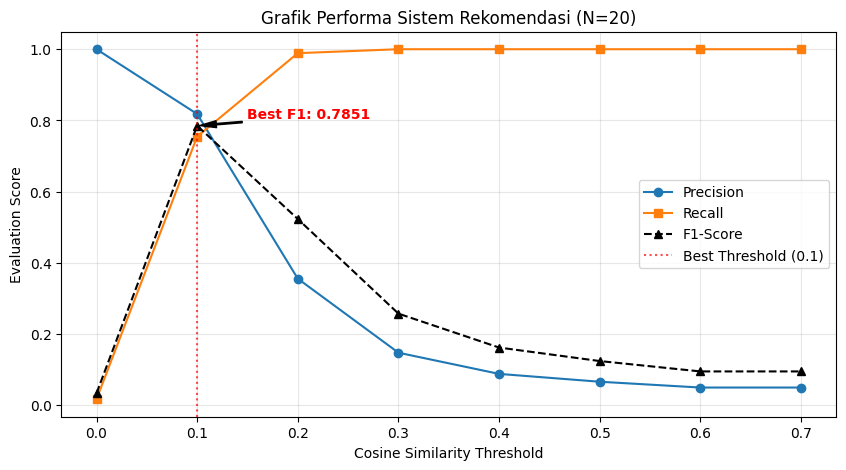

In [77]:
k_visual = 20
df_plot = df_summary[df_summary['K'] == k_visual]


best_point = df_plot.loc[df_plot['F1'].idxmax()]
x_best = best_point['Threshold']
y_best = best_point['F1']


plt.figure(figsize=(10, 5))
plt.plot(df_plot['Threshold'], df_plot['Precision'], marker='o', label='Precision')
plt.plot(df_plot['Threshold'], df_plot['Recall'], marker='s', label='Recall')
plt.plot(df_plot['Threshold'], df_plot['F1'], marker='^', linestyle='--', color='black', label='F1-Score')
plt.axvline(x=x_best, color='red', linestyle=':', alpha=0.7, label=f'Best Threshold ({x_best})')
plt.annotate(f'Best F1: {y_best:.4f}', 
             xy=(x_best, y_best), xytext=(x_best+0.05, y_best+0.02),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold', color='red')


plt.title(f'Grafik Performa Sistem Rekomendasi (N={k_visual})')
plt.xlabel('Cosine Similarity Threshold')
plt.ylabel('Evaluation Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [78]:
def show_cosine_step_by_step(doc_num_1, doc_num_2, df, tfidf_matrix, cos_matrix):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    dense = tfidf_matrix.toarray()

    d_id1, d_id2 = f"doc{doc_num_1}", f"doc{doc_num_2}"

    try:
        idx1 = df.index[df['id_document'] == d_id1][0]
        idx2 = df.index[df['id_document'] == d_id2][0]
    except:
        print("\n[Error] ID Dokumen tidak ditemukan."); return

    v_a, v_b = dense[idx1], dense[idx2]
    dot = np.dot(v_a, v_b)
    n_a, n_b = np.sqrt(np.sum(v_a**2)), np.sqrt(np.sum(v_b**2))
    score = dot / (n_a * n_b) if (n_a * n_b) > 0 else 0

    print(f"\n{'='*25} VALIDASI MANUAL {'='*25}")
    print(f"Doc A: {df.loc[idx1, 'judul_artikel']}")
    print(f"Doc B: {df.loc[idx2, 'judul_artikel']}")
    print(f"{'-'*67}")
    print(f"1. Dot Product (A·B)     : {dot:.4f}")
    print(f"2. Norm A * Norm B       : {(n_a * n_b):.4f}")
    print(f"3. Skor Cosine Manual    : {score:.4f}")
    print(f"4. Skor Matriks Sklearn  : {cos_matrix[idx1][idx2]:.4f}")
    print(f"STATUS VALIDASI          : {'✓ IDENTIK' if np.isclose(score, cos_matrix[idx1][idx2]) else '✗ BERBEDA'}")
    print(f"{'='*67}")

# Eksekusi Uji Manual
print("\nUJI VALIDASI MANUAL")
d1_input = int(input("Masukkan nomor Dokumen A (misal: 1): "))
d2_input = int(input("Masukkan nomor Dokumen B (misal: 2): "))
show_cosine_step_by_step(d1_input, d2_input, df_final, tfidf_matrix, cosine_sim)


UJI VALIDASI MANUAL

========================= VALIDASI MANUAL =========================
Doc A: RELATIVE RISK ANALYSIS OF THE SPREAD OF COVID-19 VIRUS IN MEDAN CITY BY SPATIAL AND NON-SPATIAL APPROACHES
Doc B: THE ANALYSIS OF SOCIO-ECONOMIC EFFECT ON CRIMINALITY IN INDONESIA USING FUZZY CLUSTERWISE REGRESSION MODEL
-------------------------------------------------------------------
1. Dot Product (A·B)     : 34.7352
2. Norm A * Norm B       : 7630.4097
3. Skor Cosine Manual    : 0.0046
4. Skor Matriks Sklearn  : 0.0046
STATUS VALIDASI          : ✓ IDENTIK


In [79]:
def evaluasi_manual_per_dokumen(doc_num, k=5, thr=0.2):
    doc_id = f"doc{doc_num}"
    try:
        q_idx = df_final.index[df_final['id_document'] == doc_id][0]
    except:
        print(f"Dokumen {doc_id} tidak ditemukan."); return
    sim_scores = cosine_sim[q_idx]
    ranked_indices = np.argsort(sim_scores)[::-1][1 : k+1]
    rel_indices = np.where(sim_scores >= thr)[0]
    rel_indices = rel_indices[rel_indices != q_idx]
    hits_indices = list(set(ranked_indices) & set(rel_indices))
    hits = len(hits_indices)
    precision = hits / k
    recall = hits / len(rel_indices) if len(rel_indices) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n{'='*20} EVALUASI MANUAL DOKUMEN: {doc_id} {'='*20}")
    print(f"Judul Query: {df_final.loc[q_idx, 'judul_artikel']}")
    print(f"Parameter  : K={k}, Threshold={thr}")
    print(f"{'-'*70}")
  
    res_data = []
    for rank, idx in enumerate(ranked_indices, 1):
        is_rel = "YA" if idx in rel_indices else "TIDAK"
        res_data.append([rank, df_final.loc[idx, 'id_document'], df_final.loc[idx, 'judul_artikel'], f"{sim_scores[idx]:.4f}", is_rel])
    
    print("\nTABEL HASIL REKOMENDASI SISTEM:")
    print(tabulate(res_data, headers=['Rank', 'ID', 'Judul Artikel', 'Sim Score', 'Relevan?'], tablefmt='fancy_grid'))
    
    print(f"\nRINGKASAN PERHITUNGAN:")
    print(f"- Jumlah Dokumen Relevan di Korpus (S >= {thr}): {len(rel_indices)}")
    print(f"- Jumlah Dokumen Relevan Ditemukan (Hits)   : {hits}")
    print(f"- Precision@{k} : {precision:.4f} ({precision*100:.2f}%)")
    print(f"- Recall@{k}    : {recall:.4f} ({recall*100:.2f}%)")
    print(f"- F1-Score@{k}  : {f1:.4f} ({f1*100:.2f}%)")

no_dok = int(input("Masukkan nomor dokumen sampel untuk evaluasi manual: "))
evaluasi_manual_per_dokumen(no_dok, k=5, thr=0.2)


==================== EVALUASI MANUAL DOKUMEN: doc66 ====================
Judul Query: RELATIVE RISK ANALYSIS OF THE SPREAD OF COVID-19 VIRUS IN MEDAN CITY BY SPATIAL AND NON-SPATIAL APPROACHES
Parameter  : K=5, Threshold=0.2
----------------------------------------------------------------------

TABEL HASIL REKOMENDASI SISTEM:
╒════════╤════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════════╤════════════╕
│   Rank │ ID     │ Judul Artikel                                                                                                                                            │   Sim Score │ Relevan?   │
╞════════╪════════╪══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪═════════════╪════════════╡
│      1 │ doc184 │ RELATIVE RISK OF CORONAVIRUS DISEASE (COVID-

## Get Recommendation

In [80]:
def get_recommendations(id_document, top_n=5):
    idx = df_manual_selected.index[df_manual_selected['id_document'] == id_document].tolist()
    if not idx:
        print(f"ID dokumen '{id_document}' tidak ditemukan.")
        return
    idx = idx[0]
    judul_artikel = df_manual_selected.loc[idx, 'judul_artikel']
    print(f"Rekomendasi untuk ID Dokumen: {id_document} - {judul_artikel}\n")
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = [(i, s) for i, s in sim_scores if i != idx]
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[:top_n]
    rec_indices = [i for i, _ in sim_scores]
    result = df_manual_selected.loc[rec_indices, ['id_document', 'judul_artikel', 
                                                   'kata_kunci', 'abstrak']].copy()
    result['similarity_score'] = [round(s, 4) for _, s in sim_scores]
    result['ranking'] = range(1, len(result) + 1)
    result = result.reset_index(drop=True)
    
    return result

In [81]:
dropdown = widgets.Dropdown(
    options=df_manual_selected['id_document'].tolist(),
    description='ID Dokumen:',
    layout=widgets.Layout(width='400px')
)
button = widgets.Button(description='Cari Rekomendasi', button_style='primary')
output = widgets.Output()
def on_click(b):
    output.clear_output()
    with output:
        hasil = get_recommendations(id_document=dropdown.value, top_n=5)
        display(hasil)
button.on_click(on_click)
display(dropdown, button, output)

Dropdown(description='ID Dokumen:', layout=Layout(width='400px'), options=('doc1', 'doc2', 'doc3', 'doc4', 'do…

Button(button_style='primary', description='Cari Rekomendasi', style=ButtonStyle())

Output()

## GUI preparation

> load dataset for streamlit

### raw data

In [82]:
dataset  = pd.read_csv("/Users/macbookair/Script/Skripsi/utils/DATASET/fix_recommendation_system_dataset.csv")
dataset.head()

,no,id_document,tahun_terbit,nama_jurnal,judul_artikel,nama_penulis,kata_kunci,abstrak
0,1,doc1,2025,"ZERO: Jurnal Sains, Matermatika, dan Terapan","Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia","Arie Wahyu Wijayanto, Rindang Bangun Prasetyo, Salwa Rizqina Putri, Sugiarto Sugiarto, Waris Marsisno, Krismanti Tri Wahyuni, Ernawati Pasaribu, Meilinda F N Maghfiroh",Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,"The rapid conversion of farmland to non-agricultural uses in West Java threatens food security, farmer livelihoods, and environmental sustainability. This study investigates the causes and consequences of land conversion in West Bandung and Purwakarta Regencies using a mixed-source data, including geotagging, CAPI, and secondary data from satellite images, focusing on landowners who converted farmland between 2013 and 2021. Multiple linear regression and spatial models, including Spatial Lag Model (SLM), were applied to assess key determinants. The results revealed economic pressures as the main driver, with rice fields most affected and various geographic and infrastructure factors influencing outcomes. The findings underscore the need for targeted policies to balance development with sustainable land and food system management."
1,2,doc2,2025,"ZERO: Jurnal Sains, Matermatika, dan Terapan",Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,"Sarwadi Sarwadi, Rika Rosnelly, Budi Triandi",Narcissistic Personality Disorder; Principal Component Analysis; Naïve Bayes; Feature Selection; Machine Learning.,"The mental health illness known as narcissistic personality disorder (NPD) affects a person's capacity to preserve harmonious social interactions. Early diagnosis plays a crucial role in providing timely intervention and treatment. This study examines the effectiveness of Principal Component Analysis (PCA) for feature selection in diagnosing NPD using the Naïve Bayes algorithm. The dataset utilized in this research was sourced from Open Psychometrics via Kaggle, followed by preprocessing, including data cleaning and dimensionality reduction through PCA. This study compares the performance of three Naïve Bayes models, Gaussian, Bernoulli, and Multinomial, to identify the most suitable classification approach. The findings reveal that Gaussian Naïve Bayes, when integrated with PCA, achieves the highest accuracy (91%), surpassing Bernoulli Naïve Bayes (80%) and Multinomial Naïve Bayes (69%). Implementing PCA significantly enhances computational efficiency and improves classification performance by eliminating irrelevant features and reducing data dimensionality. These results suggest combining PCA with Gaussian Naïve Bayes is a promising strategy for automating NPD diagnosis. Additionally, this study highlights the potential of machine learning in mental health evaluation and establishes the framework for further studies on hybrid models or other methods to improve prediction accuracy."
2,3,doc3,2025,"ZERO: Jurnal Sains, Matermatika, dan Terapan",Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency,"Sarni Maniar Berliana, Rafidah Abd Karim, Rita Yuliana, Budyanra Budyanra, Achmad Prasetyo, Arya Candra Kusuma, Priatmadani Priatmadani",Count Data; Excess Zeros; Job Transitions; Tourism Industry; Zero-Inflated; Poisson,"This study examines job transition patterns among 868 tourism workers in Malang, Indonesia, a key tourism hub, using 2023 Fieldwork Training data from Politeknik Statistika STIS. It aims to model transitions while addressing the high number of workers with no job changes using a Zero-Inflated Poisson (ZIP) model, which better captures these patterns than standard models. The ZIP model, including sex, age, relationsh

In [83]:
from langdetect import detect, DetectorFactory
import numpy as np

DetectorFactory.seed = 42

# =========================================
# FUNCTION DETEKSI BAHASA
# =========================================

def detect_language(text):

    try:
        return detect(str(text))

    except:
        return 'unknown'

# =========================================
# DETEKSI BAHASA TIAP KOLOM
# =========================================

dataset['judul_language'] = (
    dataset['judul_artikel']
    .apply(detect_language)
)

dataset['kata_kunci_language'] = (
    dataset['kata_kunci']
    .apply(detect_language)
)

dataset['abstrak_language'] = (
    dataset['abstrak']
    .apply(detect_language)
)

# =========================================
# FILTER DOKUMEN INDONESIA
# =========================================

data_indonesia = dataset[
    (dataset['judul_language'] == 'id') |
    (dataset['kata_kunci_language'] == 'id') |
    (dataset['abstrak_language'] == 'id')
]

print(
    f"Jumlah dokumen Bahasa Indonesia: {len(data_indonesia)}"
)

# =========================================
# TRANSLATE INDONESIA → ENGLISH
# =========================================

dataset['judul_en'] = (
    dataset['judul_artikel']
    .apply(translate_id_to_en)
)

dataset['kata_kunci_en'] = (
    dataset['kata_kunci']
    .apply(translate_id_to_en)
)

dataset['abstrak_en'] = (
    dataset['abstrak']
    .apply(translate_id_to_en)
)

# =========================================
# REPLACE NON ENGLISH → ENGLISH
# =========================================

dataset['judul_artikel'] = np.where(

    dataset['judul_language'] != 'en',

    dataset['judul_en'],

    dataset['judul_artikel']
)

dataset['kata_kunci'] = np.where(

    dataset['kata_kunci_language'] != 'en',

    dataset['kata_kunci_en'],

    dataset['kata_kunci']
)

dataset['abstrak'] = np.where(

    dataset['abstrak_language'] != 'en',

    dataset['abstrak_en'],

    dataset['abstrak']
)

# =========================================
# CEK HASIL
# =========================================

dataset[
    [
        'judul_artikel',
        'kata_kunci',
        'abstrak'
    ]
].head()

Jumlah dokumen Bahasa Indonesia: 26


,judul_artikel,kata_kunci,abstrak
0,"Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia",Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,"The rapid conversion of farmland to non-agricultural uses in West Java threatens food security, farmer livelihoods, and environmental sustainability. This study investigates the causes and consequences of land conversion in West Bandung and Purwakarta Regencies using a mixed-source data, including geotagging, CAPI, and secondary data from satellite images, focusing on landowners who converted farmland between 2013 and 2021. Multiple linear regression and spatial models, including Spatial Lag Model (SLM), were applied to assess key determinants. The results revealed economic pressures as the main driver, with rice fields most affected and various geographic and infrastructure factors influencing outcomes. The findings underscore the need for targeted policies to balance development with sustainable land and food system management."
1,Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,Narcissistic Personality Disorder; Principal Component Analysis; Naïve Bayes; Feature Selection; Machine Learning.,"The mental health illness known as narcissistic personality disorder (NPD) affects a person's capacity to preserve harmonious social interactions. Early diagnosis plays a crucial role in providing timely intervention and treatment. This study examines the effectiveness of Principal Component Analysis (PCA) for feature selection in diagnosing NPD using the Naïve Bayes algorithm. The dataset utilized in this research was sourced from Open Psychometrics via Kaggle, followed by preprocessing, including data cleaning and dimensionality reduction through PCA. This study compares the performance of three Naïve Bayes models, Gaussian, Bernoulli, and Multinomial, to identify the most suitable classification approach. The findings reveal that Gaussian Naïve Bayes, when integrated with PCA, achieves the highest accuracy (91%), surpassing Bernoulli Naïve Bayes (80%) and Multinomial Naïve Bayes (69%). Implementing PCA significantly enhances computational efficiency and improves classification performance by eliminating irrelevant features and reducing data dimensionality. These results suggest combining PCA with Gaussian Naïve Bayes is a promising strategy for automating NPD diagnosis. Additionally, this study highlights the potential of machine learning in mental health evaluation and establishes the framework for further studies on hybrid models or other methods to improve prediction accuracy."
2,Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency,Count Data; Excess Zeros; Job Transitions; Tourism Industry; Zero-Inflated; Poisson,"This study examines job transition patterns among 868 tourism workers in Malang, Indonesia, a key tourism hub, using 2023 Fieldwork Training data from Politeknik Statistika STIS. It aims to model transitions while addressing the high number of workers with no job changes using a Zero-Inflated Poisson (ZIP) model, which better captures these patterns than standard models. The ZIP model, including sex, age, relationship to the head of household, education, and foreign language proficiency, shows that proficient workers are more likely to remain in stable roles, while men and younger workers exhibit greater mobility, particularly when leveraging language skills. These findings support Indonesia’s Sertifikasi Kompetensi SDM Pariwisata program by justifying targeted interventions: language training to enhance mobility for non-proficient workers, mentorship for female tour guides to address gender disparities, and digital skills programs for older workers to boost employability. These strategies

In [84]:
dataset.head()

,no,id_document,tahun_terbit,nama_jurnal,judul_artikel,nama_penulis,kata_kunci,abstrak,judul_language,kata_kunci_language,abstrak_language,judul_en,kata_kunci_en,abstrak_en
0,1,doc1,2025,"ZERO: Jurnal Sains, Matermatika, dan Terapan","Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia","Arie Wahyu Wijayanto, Rindang Bangun Prasetyo, Salwa Rizqina Putri, Sugiarto Sugiarto, Waris Marsisno, Krismanti Tri Wahyuni, Ernawati Pasaribu, Meilinda F N Maghfiroh",Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,"The rapid conversion of farmland to non-agricultural uses in West Java threatens food security, farmer livelihoods, and environmental sustainability. This study investigates the causes and consequences of land conversion in West Bandung and Purwakarta Regencies using a mixed-source data, including geotagging, CAPI, and secondary data from satellite images, focusing on landowners who converted farmland between 2013 and 2021. Multiple linear regression and spatial models, including Spatial Lag Model (SLM), were applied to assess key determinants. The results revealed economic pressures as the main driver, with rice fields most affected and various geographic and infrastructure factors influencing outcomes. The findings underscore the need for targeted policies to balance development with sustainable land and food system management.",en,en,en,"Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia",Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,"The rapid conversion of farmland to non-agricultural uses in West Java threatens food security, farmer livelihoods, and environmental sustainability. This study investigates the causes and consequences of land conversion in West Bandung and Purwakarta Regencies using a mixed-source data, including geotagging, CAPI, and secondary data from satellite images, focusing on landowners who converted farmland between 2013 and 2021. Multiple linear regression and spatial models, including Spatial Lag Model (SLM), were applied to assess key determinants. The results revealed economic pressures as the main driver, with rice fields most affected and various geographic and infrastructure factors influencing outcomes. The findings underscore the need for targeted policies to balance development with sustainable land and food system management."
1,2,doc2,2025,"ZERO: Jurnal Sains, Matermatika, dan Terapan",Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,"Sarwadi Sarwadi, Rika Rosnelly, Budi Triandi",Narcissistic Personality Disorder; Principal Component Analysis; Naïve Bayes; Feature Selection; Machine Learning.,"The mental health illness known as narcissistic personality disorder (NPD) affects a person's capacity to preserve harmonious social interactions. Early diagnosis plays a crucial role in providing timely intervention and treatment. This study examines the effectiveness of Principal Component Analysis (PCA) for feature selection in diagnosing NPD using the Naïve Bayes algorithm. The dataset utilized in this research was sourced from Open Psychometrics via Kaggle, followed by preprocessing, including data cleaning and dimensionality reduction through PCA. This study compares the performance of three Naïve Bayes models, Gaussian, Bernoulli, and Multinomial, to identify the most suitable classification approach. The findings reveal that Gaussian Naïve Bayes, when integrated with PCA, achieves the highest accuracy (91%), surpassing Bernoulli Naïve Bayes (80%) and Multinomial Naïve Bayes (69%). Implementing PCA significantly enhances computational efficiency and improves classification performance by eliminating irrelevant features and reducing data dimensionality. Th

In [85]:
raw_dataset = dataset[["id_document", "judul_artikel", "kata_kunci", "abstrak"]].copy()
raw_dataset.head()

,id_document,judul_artikel,kata_kunci,abstrak
0,doc1,"Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia",Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,"The rapid conversion of farmland to non-agricultural uses in West Java threatens food security, farmer livelihoods, and environmental sustainability. This study investigates the causes and consequences of land conversion in West Bandung and Purwakarta Regencies using a mixed-source data, including geotagging, CAPI, and secondary data from satellite images, focusing on landowners who converted farmland between 2013 and 2021. Multiple linear regression and spatial models, including Spatial Lag Model (SLM), were applied to assess key determinants. The results revealed economic pressures as the main driver, with rice fields most affected and various geographic and infrastructure factors influencing outcomes. The findings underscore the need for targeted policies to balance development with sustainable land and food system management."
1,doc2,Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,Narcissistic Personality Disorder; Principal Component Analysis; Naïve Bayes; Feature Selection; Machine Learning.,"The mental health illness known as narcissistic personality disorder (NPD) affects a person's capacity to preserve harmonious social interactions. Early diagnosis plays a crucial role in providing timely intervention and treatment. This study examines the effectiveness of Principal Component Analysis (PCA) for feature selection in diagnosing NPD using the Naïve Bayes algorithm. The dataset utilized in this research was sourced from Open Psychometrics via Kaggle, followed by preprocessing, including data cleaning and dimensionality reduction through PCA. This study compares the performance of three Naïve Bayes models, Gaussian, Bernoulli, and Multinomial, to identify the most suitable classification approach. The findings reveal that Gaussian Naïve Bayes, when integrated with PCA, achieves the highest accuracy (91%), surpassing Bernoulli Naïve Bayes (80%) and Multinomial Naïve Bayes (69%). Implementing PCA significantly enhances computational efficiency and improves classification performance by eliminating irrelevant features and reducing data dimensionality. These results suggest combining PCA with Gaussian Naïve Bayes is a promising strategy for automating NPD diagnosis. Additionally, this study highlights the potential of machine learning in mental health evaluation and establishes the framework for further studies on hybrid models or other methods to improve prediction accuracy."
2,doc3,Zero Inflated Poisson Regression for Analyzing Excess Zeros in Job Transition Data: A Case Study of Tourism Workers in Malang Regency,Count Data; Excess Zeros; Job Transitions; Tourism Industry; Zero-Inflated; Poisson,"This study examines job transition patterns among 868 tourism workers in Malang, Indonesia, a key tourism hub, using 2023 Fieldwork Training data from Politeknik Statistika STIS. It aims to model transitions while addressing the high number of workers with no job changes using a Zero-Inflated Poisson (ZIP) model, which better captures these patterns than standard models. The ZIP model, including sex, age, relationship to the head of household, education, and foreign language proficiency, shows that proficient workers are more likely to remain in stable roles, while men and younger workers exhibit greater mobility, particularly when leveraging language skills. These findings support Indonesia’s Sertifikasi Kompetensi SDM Pariwisata program by justifying targeted interventions: language training to enhance mobility for non-proficient workers, mentorship for female tour guides to address gender disparities, and digital skills programs for older workers to boost empl

In [86]:
raw_dataset.to_csv("/Users/macbookair/Script/Skripsi/utils/DATASET/raw_dataset.csv", index=False)

### Dataset final

In [87]:
dataset_final = df_manual_selected[["id_document", "judul_artikel", "kata_kunci", "abstrak","case_folding_judul","case_folding_kata_kunci","case_folding_abstrak", "combined"]].copy()
dataset_final.head()

,id_document,judul_artikel,kata_kunci,abstrak,case_folding_judul,case_folding_kata_kunci,case_folding_abstrak,combined
0,doc1,"Drivers and Impacts of Agricultural Land Conversion: Regression Modelling with Spatial Dependence in West Bandung and Purwakarta Regencies, Indonesia",Agricultural Land; Land Conversion; Land-owning Farmers; Spatial Lag Model,"The rapid conversion of farmland to non-agricultural uses in West Java threatens food security, farmer livelihoods, and environmental sustainability. This study investigates the causes and consequences of land conversion in West Bandung and Purwakarta Regencies using a mixed-source data, including geotagging, CAPI, and secondary data from satellite images, focusing on landowners who converted farmland between 2013 and 2021. Multiple linear regression and spatial models, including Spatial Lag Model (SLM), were applied to assess key determinants. The results revealed economic pressures as the main driver, with rice fields most affected and various geographic and infrastructure factors influencing outcomes. The findings underscore the need for targeted policies to balance development with sustainable land and food system management.",drivers and impacts of agricultural land conversion regression modelling with spatial dependence in west bandung and purwakarta regencies indonesia,agricultural land land conversion landowning farmers spatial lag model,the rapid conversion of farmland to nonagricultural uses in west java threatens food security farmer livelihoods and environmental sustainability this study investigates the causes and consequences of land conversion in west bandung and purwakarta regencies using a mixedsource data including geotagging capi and secondary data from satellite images focusing on landowners who converted farmland between and multiple linear regression and spatial models including spatial lag model slm were applied to assess key determinants the results revealed economic pressures as the main driver with rice fields most affected and various geographic and infrastructure factors influencing outcomes the findings underscore the need for targeted policies to balance development with sustainable land and food system management,driver impact agricultural land conversion regression model spatial dependence west bandung purwakarta regency indonesia agricultural land land conversion landowning farmer spatial lag rapid conversion farmland nonagricultural use west java threatens food security farmer livelihood environmental sustainability investigate cause consequence land conversion west bandung purwakarta regency mixedsource include geotagging capi secondary satellite image focus landowner convert farmland multiple linear regression spatial include spatial lag slm assess key determinant reveal economic pressure main driver rice field affect various geographic infrastructure factor influence outcome underscore need targeted policy balance development sustainable land food management
1,doc2,Feature Selection Analysis for Diagnosing Narcissistic Personality Disorder (NPD) Using Principal Component Analysis and the Naïve Bayes Model,Narcissistic Personality Disorder; Principal Component Analysis; Naïve Bayes; Feature Selection; Machine Learning.,"The mental health illness known as narcissistic personality disorder (NPD) affects a person's capacity to preserve harmonious social interactions. Early diagnosis plays a crucial role in providing timely intervention and treatment. This study examines the effectiveness of Principal Component Analysis (PCA) for feature selection in diagnosing NPD using the Naïve Bayes algorithm. The dataset utilized in this research was sourced from Open Psychometrics via Kaggle, followed by preprocessing, including data cleaning and dimensionality reduction through PCA. This study compares the performance of three Naïve Bayes models, Gaussian, Bernoulli, and Multinomial, to identify the most suitable classification approach. The findings reveal 

In [88]:
dataset_final.to_csv("/Users/macbookair/Script/Skripsi/utils/recommendation_system/data/dataset_final.csv", index=False)

In [93]:
Title = "IMPLEMENTASI CONTENT-BASED FILTERING UNTUK SISTEM REKOMENDASI ARTIKEL JURNAL STATISTIKA MENGGUNAKAN TF-IDF DAN COSINE SIMILARITY"
Title = str(Title)

In [119]:
Abstract = "Penelitian ini bertujuan untuk mengimplementasikan metode Content-Based Filtering dalam membangun sistem rekomendasi artikel jurnal berdasarkan kemiripan topik penelitian."
Abstract = str(Abstract)

In [120]:
Title_casefold = case_folding(Title)
Abstract_casefold = case_folding(Abstract)

In [121]:
abstract_translate = translate_id_to_en(Abstract_casefold)

In [122]:
print(abstract_translate)

This research aims to implement the content-based filtering method in building a system of recommendation journal articles based on the resemblance of research subjects.


In [104]:
title_translate = translate_id_to_en(Title_casefold)

In [105]:
print(title_translate)

implemented content-based filtering for system recommendations of statistical journal articles using tf-idf and cosine similarity
